In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/train.csv")

In [ ]:
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
categorical_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']

for col in categorical_cols:
    print(f"--- Column: {col} ---")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Value counts:")
    display(df[col].value_counts())
    print("\n")

--- Column: Gender ---
Number of unique values: 3
Value counts:


,count
Gender,
Male,367954
Female,295427
Other,5284




--- Column: City_Type ---
Number of unique values: 3
Value counts:


,count
City_Type,
Urban,289305
Suburban,255377
Rural,123983




--- Column: Current_Car_Type ---
Number of unique values: 4
Value counts:


...

,count
Subsidy_Available,
Yes,419909
No,248756




--- Column: Range_Anxiety_Level ---
Number of unique values: 3
Value counts:


,count
Range_Anxiety_Level,
Low,603972
Medium,62499
High,2194




--- Column: Will_Buy_EV ---
Number of unique values: 2
Value counts:


,count
Will_Buy_EV,
No,551886
Yes,116779


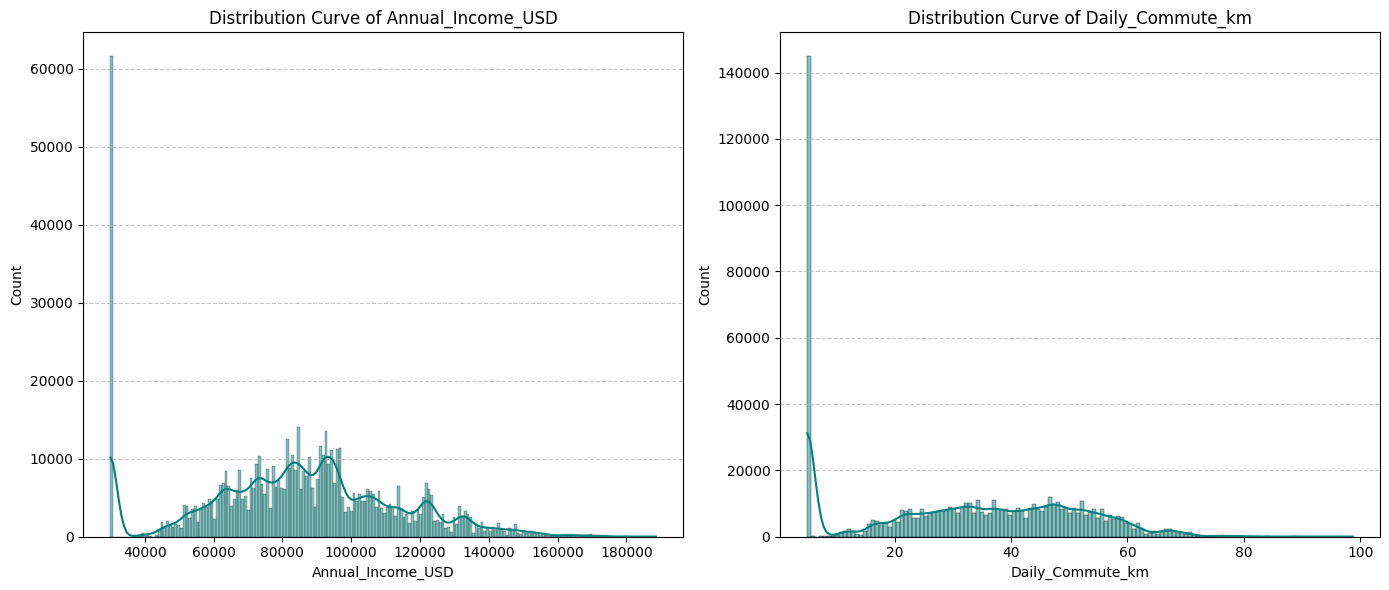

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to plot
plot_cols = ['Annual_Income_USD', 'Daily_Commute_km']

plt.figure(figsize=(14, 6))

for i, col in enumerate(plot_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df[col].dropna(), kde=True, color='teal')
    plt.title(f'Distribution Curve of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Statistical Analysis: ANOVA, Chi-Square, and Covariance

In [ ]:
import scipy.stats as stats
import pandas as pd

# 1. ANOVA Test (Numerical vs Categorical)
# Does Annual_Income_USD differ significantly between those who Will_Buy_EV vs those who won't?
groups = [df[df['Will_Buy_EV'] == val]['Annual_Income_USD'].dropna() for val in df['Will_Buy_EV'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA Results (Annual_Income_USD vs Will_Buy_EV):")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

ANOVA Results (Annual_Income_USD vs Will_Buy_EV):
F-statistic: 35900.1055, p-value: 0.0000e+00


In [ ]:
# 2. Chi-Square Test (Categorical vs Categorical)
# Is there a significant relationship between City_Type and Will_Buy_EV?
contingency_table = pd.crosstab(df['City_Type'], df['Will_Buy_EV'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Results (City_Type vs Will_Buy_EV):")
print(f"Chi2-statistic: {chi2:.4f}, p-value: {p:.4e}")

Chi-Square Results (City_Type vs Will_Buy_EV):
Chi2-statistic: 742.8302, p-value: 4.9713e-162


In [ ]:
# 3. Covariance Matrix
# Calculating covariance between numerical features
num_df = df[['Age', 'Annual_Income_USD', 'Daily_Commute_km']].dropna()
cov_matrix = num_df.cov()

print("Covariance Matrix:")
display(cov_matrix)

Covariance Matrix:


,Age,Annual_Income_USD,Daily_Commute_km
Age,165.777168,-1.681754e+03,-1.576607
Annual_Income_USD,-1681.753573,8.207096e+08,4289.527352
Daily_Commute_km,-1.576607,4.289527e+03,350.830652


In [ ]:
import scipy.stats as stats

target = 'Will_Buy_EV'
categorical_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
numerical_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

print("=== CHI-SQUARE TESTS (Categorical vs Will_Buy_EV) ===")
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"{col:25} | Chi2: {chi2:10.2f} | p-value: {p:.4e}")

print("\n=== ANOVA TESTS (Numerical vs Will_Buy_EV) ===")
for col in numerical_cols:
    # Drop NaNs for the specific column to ensure valid test
    temp_df = df[[col, target]].dropna()
    groups = [temp_df[temp_df[target] == val][col] for val in temp_df[target].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col:25} | F-stat: {f_stat:10.2f} | p-value: {p_val:.4e}")

=== CHI-SQUARE TESTS (Categorical vs Will_Buy_EV) ===
Gender                    | Chi2:      33.04 | p-value: 6.6875e-08
City_Type                 | Chi2:     742.83 | p-value: 4.9713e-162
Current_Car_Type          | Chi2:     173.66 | p-value: 2.0603e-37
Home_Charging_Possible    | Chi2:    4671.04 | p-value: 0.0000e+00
Subsidy_Available         | Chi2:   78382.50 | p-value: 0.0000e+00
Range_Anxiety_Level       | Chi2:    8981.91 | p-value: 0.0000e+00

=== ANOVA TESTS (Numerical vs Will_Buy_EV) ===
Age                       | F-stat:      37.11 | p-value: 1.1166e-09
Annual_Income_USD         | F-stat:   35900.11 | p-value: 0.0000e+00
Daily_Commute_km          | F-stat:    1409.61 | p-value: 3.5959e-308
Number_of_Cars_Owned      | F-stat:      10.15 | p-value: 1.4443e-03
Charging_Stations_Near_Home | F-stat:     178.87 | p-value: 8.6738e-41
Charging_Stations_Near_Work | F-stat:     100.01 | p-value: 1.5234e-23
Environmental_Concern_Level | F-stat:  183537.96 | p-value: 0.0000e+00


### Data Preparation and Logistic Regression
We will use `pd.get_dummies` for encoding and `StandardScaler` for normalization before fitting the model.

Logistic Regression Accuracy: 0.895844705495278

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.66      0.69     23193

    accuracy                           0.90    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.90      0.89    133733



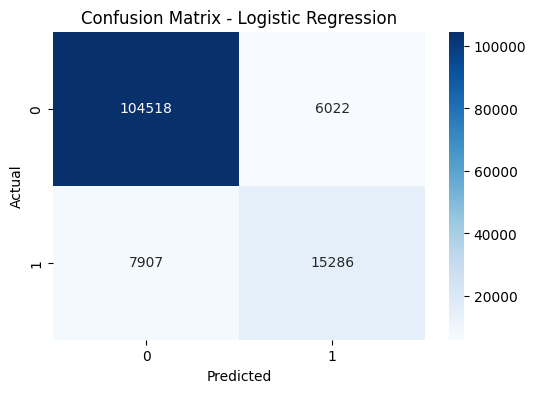

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare Features and Target
# Drop 'id' as it's just an index, and handle categorical encoding
X = df.drop(columns=['id', 'Will_Buy_EV'])
y = df['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 5. Predictions and Evaluation
y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Training Random Forest and XGBoost
We will use the same preprocessed training and testing data to ensure a fair comparison.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# 2. Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 3. Evaluate Models
print("=== Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:02:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Random Forest Results ===
Accuracy: 0.8942
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    110540
           1       0.71      0.65      0.68     23193

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733


=== XGBoost Results ===
Accuracy: 0.8989
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.68      0.70     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



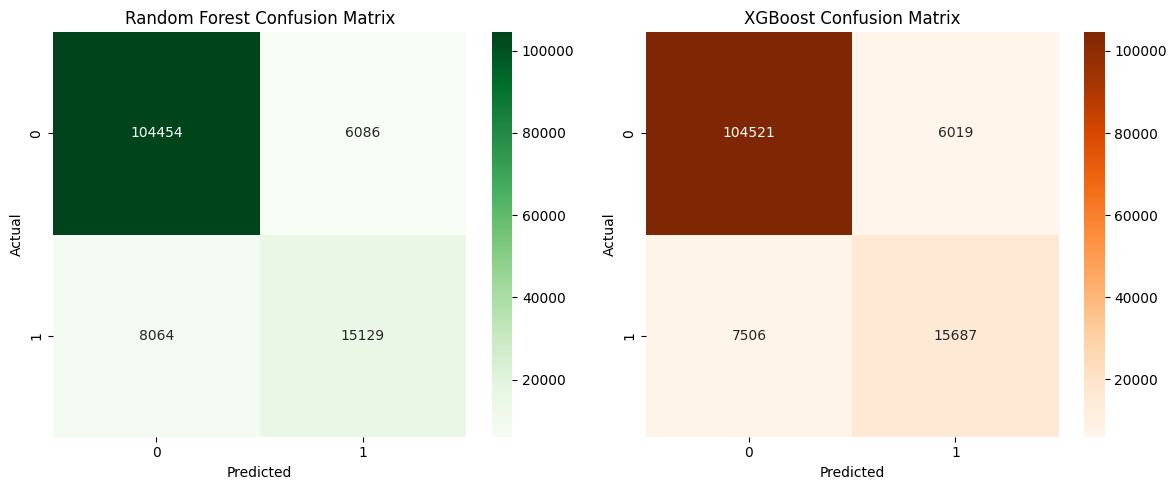

In [ ]:
# Visualize Confusion Matrices for comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Feature Importance Analysis
We will extract and visualize the feature importance from the XGBoost model to understand which factors influence the prediction the most.

/tmp/ipykernel_962/1787502224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


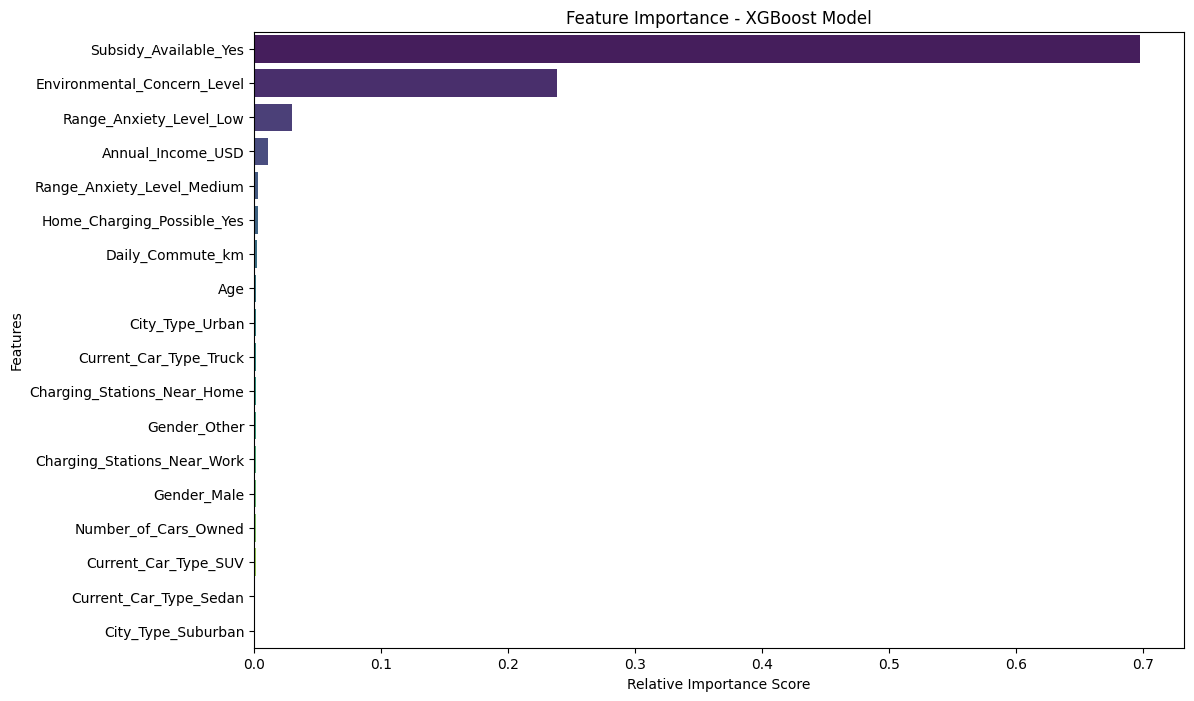

In [ ]:
import numpy as np

# Get feature importances from XGBoost
importances = xgb_model.feature_importances_
feature_names = X_encoded.columns
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.title("Feature Importance - XGBoost Model")
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.show()

### Hyperparameter Tuning with Cross-Validation (XGBoost)
We use `RandomizedSearchCV` to explore a wide range of hyperparameters efficiently and `StratifiedKFold` to maintain class balance during cross-validation.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define the parameter grid to explore
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Initialize the cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up Randomized Search
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_distributions=param_grid,
    n_iter=10, # Number of combinations to try
    scoring='f1', # Focus on F1-score to balance precision and recall
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit the search to the training data
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train_scaled, y_train)

# Get the best model
best_xgb = random_search.best_estimator_

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}")

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:10:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV F1-Score: 0.6971


=== Tuned XGBoost Final Results ===
Accuracy: 0.8994
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.73      0.67      0.70     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



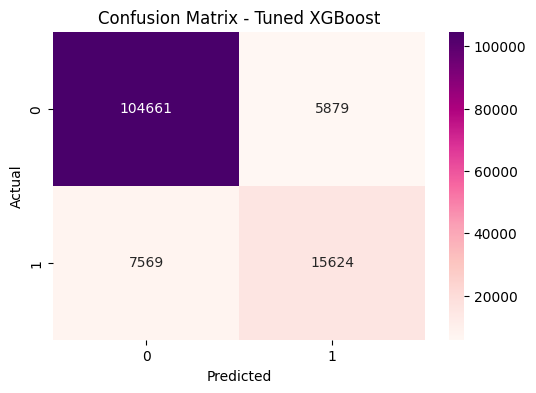

In [ ]:
# Evaluate the tuned model on the test set
y_pred_best = best_xgb.predict(X_test_scaled)

print("=== Tuned XGBoost Final Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

# Visual comparison of original vs tuned
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='RdPu')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
!pip install catboost

### Training LightGBM and CatBoost
We will evaluate these models using the same training and testing sets to maintain consistency.

In [ ]:
! pip install catboost

In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Train LightGBM
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)
lgbm_model.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

# 2. Train CatBoost
cat_model = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
cat_model.fit(X_train_scaled, y_train)
y_pred_cat = cat_model.predict(X_test_scaled)

# 3. Evaluate Models
print("=== LightGBM Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))

print("\n=== CatBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")
print(classification_report(y_test, y_pred_cat))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== LightGBM Results ===
Accuracy: 0.8984
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.67      0.70     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733


=== CatBoost Results ===
Accuracy: 0.8991
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.73      0.67      0.70     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



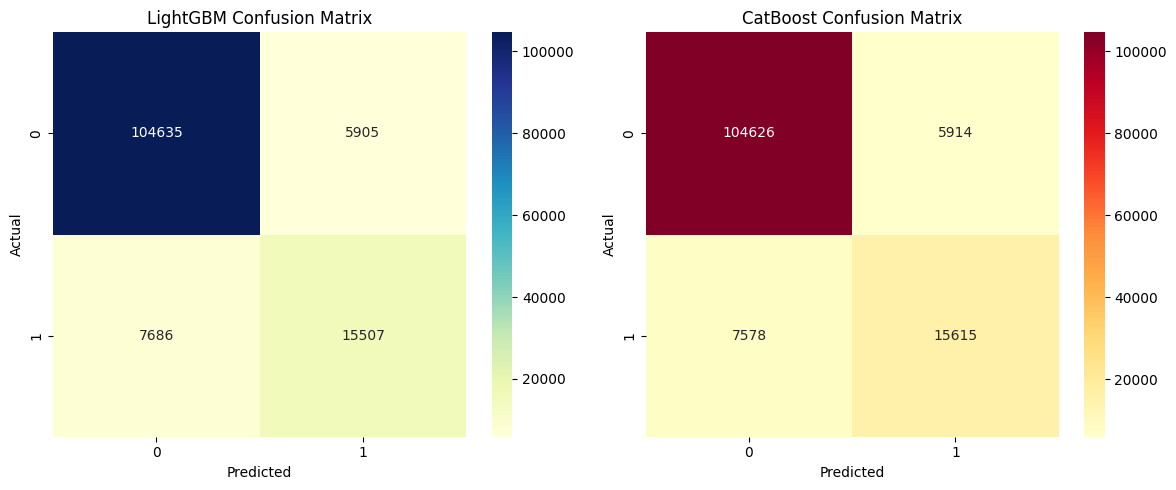

In [ ]:
# Comparison visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('LightGBM Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_cat), annot=True, fmt='d', cmap='YlOrRd', ax=ax[1])
ax[1].set_title('CatBoost Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Apply SMOTE to the training data
print(f"Original class distribution: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Resampled class distribution: {Counter(y_train_resampled)}")

Original class distribution: Counter({0: 441346, 1: 93586})
Resampled class distribution: Counter({1: 441346, 0: 441346})


Re-training best XGBoost model on balanced data...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:13:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Balanced XGBoost Final Results ===
Accuracy: 0.8960
              precision    recall  f1-score   support

           0       0.94      0.93      0.94    110540
           1       0.69      0.72      0.71     23193

    accuracy                           0.90    133733
   macro avg       0.82      0.83      0.82    133733
weighted avg       0.90      0.90      0.90    133733



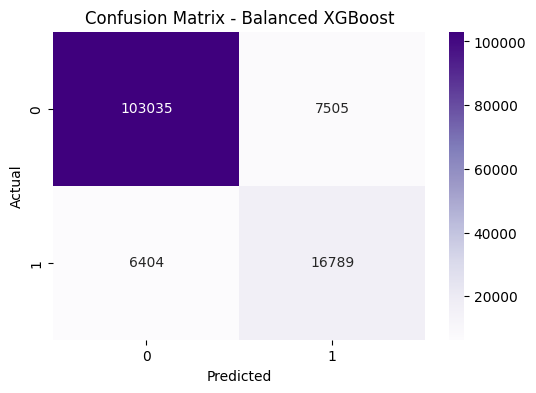

In [ ]:
# 2. Re-train the tuned XGBoost model on the balanced data
print("Re-training best XGBoost model on balanced data...")
best_xgb.fit(X_train_resampled, y_train_resampled)

# 3. Final Evaluation
y_pred_final = best_xgb.predict(X_test_scaled)

print("=== Balanced XGBoost Final Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Balanced XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Precision-Recall and ROC Curve Analysis
To improve the accuracy of Class 1 predictions, we evaluate the probability thresholds rather than just the binary output.

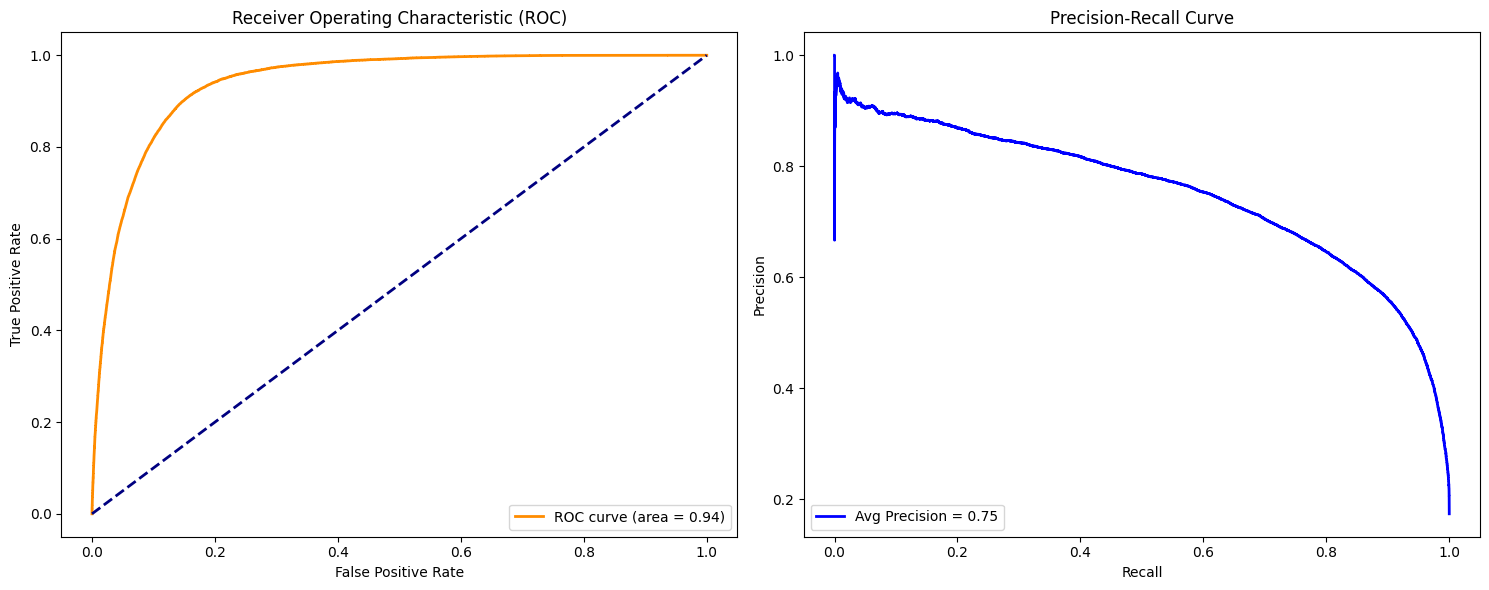

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get probability predictions for the positive class (Class 1)
y_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('Receiver Operating Characteristic (ROC)')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")

# Precision-Recall Curve
ax[1].plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {average_precision_score(y_test, y_probs):.2f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Optimal Threshold Selection
We will now look for a threshold that maximizes the F1-score specifically for the buyer class to ensure the 'most accurate' identification.

In [ ]:
# Find the threshold that maximizes the F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds_pr[np.argmax(f1_scores)]

print(f"Best Threshold for Class 1: {best_threshold:.4f}")

# Apply the new threshold
y_pred_threshold = (y_probs >= best_threshold).astype(int)

print("=== Results with Optimized Threshold ===")
print(classification_report(y_test, y_pred_threshold))

Best Threshold for Class 1: 0.4241
=== Results with Optimized Threshold ===
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    110540
           1       0.65      0.79      0.72     23193

    accuracy                           0.89    133733
   macro avg       0.80      0.85      0.82    133733
weighted avg       0.90      0.89      0.89    133733



### Increasing Precision for Class 1
If the goal is to be more 'accurate' when predicting a buyer (reducing False Positives), we increase the threshold. Let's compare a high-precision threshold against our previous results.

=== Results with High Precision Threshold (0.75) ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93    110540
           1       0.80      0.44      0.57     23193

    accuracy                           0.88    133733
   macro avg       0.85      0.71      0.75    133733
weighted avg       0.88      0.88      0.87    133733



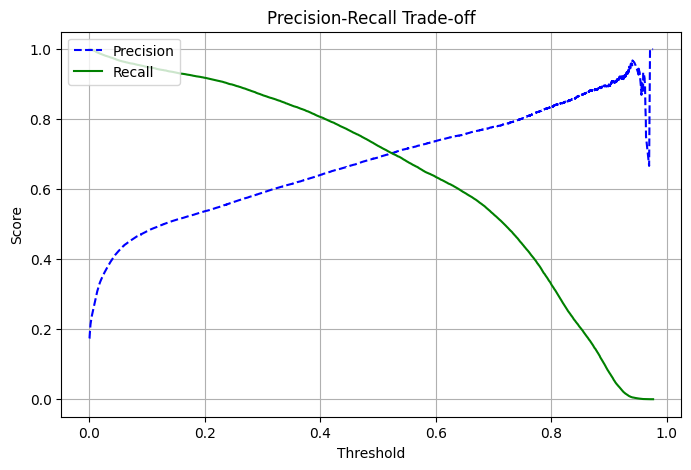

In [ ]:
# Setting a stricter threshold to increase Precision for Class 1
high_precision_threshold = 0.75
y_pred_precise = (y_probs >= high_precision_threshold).astype(int)

print(f"=== Results with High Precision Threshold ({high_precision_threshold}) ===")
print(classification_report(y_test, y_pred_precise))

# Visualize the trade-off
plt.figure(figsize=(8, 5))
plt.plot(thresholds_pr, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds_pr, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### Increasing Precision for Class 1
If the goal is to be more 'accurate' when predicting a buyer (reducing False Positives), we increase the threshold. Let's compare a high-precision threshold against our previous results.

=== Results with High Precision Threshold (0.75) ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93    110540
           1       0.80      0.44      0.57     23193

    accuracy                           0.88    133733
   macro avg       0.85      0.71      0.75    133733
weighted avg       0.88      0.88      0.87    133733



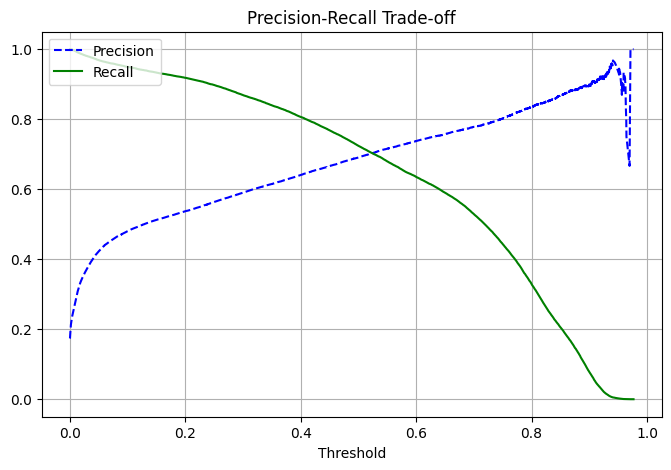

In [ ]:
# Setting a stricter threshold to increase Precision for Class 1
high_precision_threshold = 0.75
y_pred_precise = (y_probs >= high_precision_threshold).astype(int)

print(f"=== Results with High Precision Threshold ({high_precision_threshold}) ===")
print(classification_report(y_test, y_pred_precise))

# Visualize the trade-off
plt.figure(figsize=(8, 5))
plt.plot(thresholds_pr, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds_pr, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.title('Precision-Recall Trade-off')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### Final Classification Matrix
This matrix visualizes the performance of the High-Precision threshold (0.75) for the XGBoost model.

<Figure size 800x600 with 0 Axes>

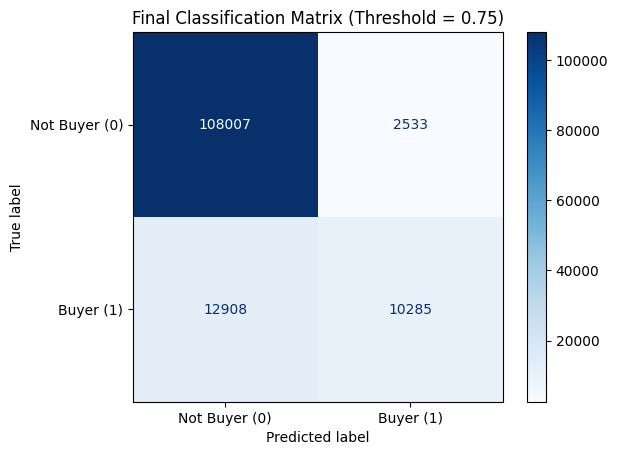

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_precise)

# Plot using ConfusionMatrixDisplay for a professional look
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Buyer (0)', 'Buyer (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Final Classification Matrix (Threshold = 0.75)')
plt.grid(False)
plt.show()

### Finding the 'Sweet Spot' (Balanced Accuracy)
We will now use a threshold of **0.58**. This aims to keep Precision high while ensuring the Recall for buyers stays above 60%, so the model identifies the majority of potential customers correctly.

=== Results with Balanced Threshold (0.58) ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.73      0.65      0.69     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.80      0.81    133733
weighted avg       0.89      0.90      0.90    133733



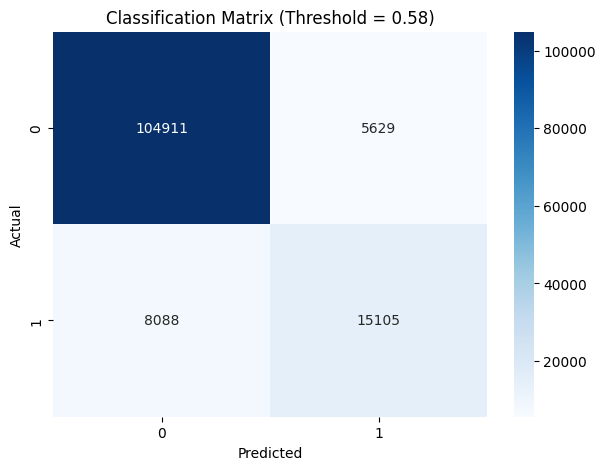

In [ ]:
# Setting a balanced threshold
balanced_threshold = 0.58
y_pred_balanced = (y_probs >= balanced_threshold).astype(int)

print(f"=== Results with Balanced Threshold ({balanced_threshold}) ===")
print(classification_report(y_test, y_pred_balanced))

# Final Comparison Matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title(f'Classification Matrix (Threshold = {balanced_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### High-Recall Strategy (Threshold = 0.25)
Setting the threshold to 0.25 to maximize the identification of potential buyers.

=== Results with Low Threshold (0.25) ===
              precision    recall  f1-score   support

           0       0.98      0.85      0.91    110540
           1       0.56      0.90      0.69     23193

    accuracy                           0.86    133733
   macro avg       0.77      0.88      0.80    133733
weighted avg       0.90      0.86      0.87    133733



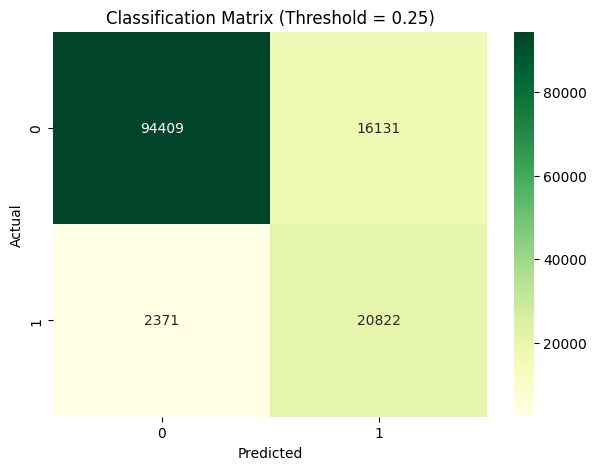

In [ ]:
# Setting a lower threshold for high recall
low_threshold = 0.25
y_pred_low = (y_probs >= low_threshold).astype(int)

print(f"=== Results with Low Threshold ({low_threshold}) ===")
print(classification_report(y_test, y_pred_low))

# Classification Matrix for Low Threshold
cm_low = confusion_matrix(y_test, y_pred_low)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_low, annot=True, fmt='d', cmap='YlGn')
plt.title(f'Classification Matrix (Threshold = {low_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Targeted Strategy (Threshold = 0.35)
Evaluating the performance at the user-specified threshold of 0.35.

=== Results with Custom Threshold (0.35) ===
              precision    recall  f1-score   support

           0       0.96      0.89      0.93    110540
           1       0.61      0.84      0.71     23193

    accuracy                           0.88    133733
   macro avg       0.79      0.86      0.82    133733
weighted avg       0.90      0.88      0.89    133733



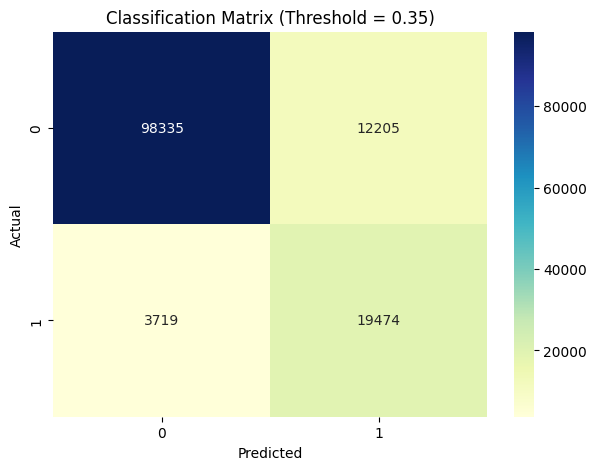

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Setting the threshold to 0.35
custom_threshold = 0.35
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"=== Results with Custom Threshold ({custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom))

# Confusion Matrix for Custom Threshold
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Classification Matrix (Threshold = {custom_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Triage Strategy (Confidence-Based Classification)
Using the model's probabilities to classify individuals into High-Confidence Buyers, High-Confidence Non-Buyers, and an 'Uncertain' group for further review.

In [ ]:
import numpy as np
import pandas as pd

def classify_with_confidence(probs, upper=0.75, lower=0.25):
    """Categorizes probabilities into three confidence buckets."""
    categories = []
    for p in probs:
        if p >= upper:
            categories.append('High-Confidence Buyer')
        elif p <= lower:
            categories.append('High-Confidence Non-Buyer')
        else:
            categories.append('Uncertain / Follow-up Needed')
    return np.array(categories)

# Apply the tiered logic to our test probabilities
triage_results = classify_with_confidence(y_probs)

# Create a summary table for a sample of the results
summary_df = pd.DataFrame({
    'Probability Score': y_probs,
    'Triage Category': triage_results
})

print("=== Triage Distribution Summary ===")
print(summary_df['Triage Category'].value_counts())

print("\n=== Sample Results ===")
display(summary_df.head(10))

=== Triage Distribution Summary ===
Triage Category
High-Confidence Non-Buyer       96780
Uncertain / Follow-up Needed    24135
High-Confidence Buyer           12818
Name: count, dtype: int64

=== Sample Results ===


,Probability Score,Triage Category
0,0.008513,High-Confidence Non-Buyer
1,0.532045,Uncertain / Follow-up Needed
2,0.001526,High-Confidence Non-Buyer
3,0.000255,High-Confidence Non-Buyer
4,0.499722,Uncertain / Follow-up Needed
5,0.030326,High-Confidence Non-Buyer
6,0.003628,High-Confidence Non-Buyer
7,0.238837,High-Confidence Non-Buyer
8,0.001250,High-Confidence Non-Buyer
9,0.003432,High-Confidence Non-Buyer


### Triage Strategy (Strict Thresholds: 0.15 and 0.85)
We are now applying a more conservative strategy to ensure the 'High-Confidence' buckets are extremely reliable.

In [ ]:
# Apply the tiered logic with new user-specified thresholds
strict_upper = 0.85
strict_lower = 0.15

strict_triage_results = classify_with_confidence(y_probs, upper=strict_upper, lower=strict_lower)

# Create a summary table
strict_summary_df = pd.DataFrame({
    'Probability Score': y_probs,
    'Triage Category': strict_triage_results
})

print(f"=== Triage Distribution (Upper: {strict_upper}, Lower: {strict_lower}) ===")
print(strict_summary_df['Triage Category'].value_counts())

print("\n=== Sample Results ===")
display(strict_summary_df.head(10))

=== Triage Distribution (Upper: 0.85, Lower: 0.15) ===
Triage Category
High-Confidence Non-Buyer       91485
Uncertain / Follow-up Needed    36751
High-Confidence Buyer            5497
Name: count, dtype: int64

=== Sample Results ===


,Probability Score,Triage Category
0,0.008513,High-Confidence Non-Buyer
1,0.532045,Uncertain / Follow-up Needed
2,0.001526,High-Confidence Non-Buyer
3,0.000255,High-Confidence Non-Buyer
4,0.499722,Uncertain / Follow-up Needed
5,0.030326,High-Confidence Non-Buyer
6,0.003628,High-Confidence Non-Buyer
7,0.238837,Uncertain / Follow-up Needed
8,0.001250,High-Confidence Non-Buyer
9,0.003432,High-Confidence Non-Buyer


Results with Custom Threshold = 0.15
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    110540
           1       0.51      0.93      0.66     23193

    accuracy                           0.83    133733
   macro avg       0.75      0.87      0.78    133733
weighted avg       0.90      0.83      0.85    133733



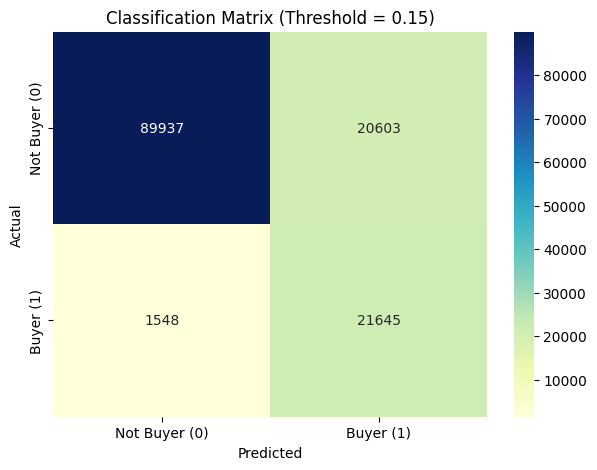

Results with Custom Threshold = 0.85
              precision    recall  f1-score   support

           0       0.86      0.99      0.92    110540
           1       0.87      0.21      0.33     23193

    accuracy                           0.86    133733
   macro avg       0.86      0.60      0.63    133733
weighted avg       0.86      0.86      0.82    133733



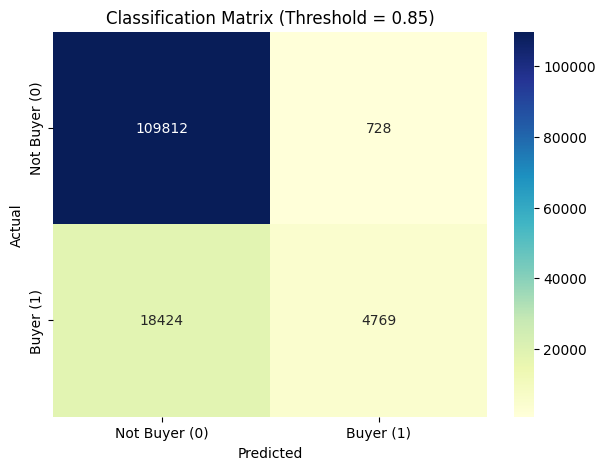

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Thresholds to evaluate
thresholds = [0.15, 0.85]

for custom_threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred_custom = (y_probs >= custom_threshold).astype(int)

    print("=" * 60)
    print(f"Results with Custom Threshold = {custom_threshold}")
    print("=" * 60)

    # Classification Report
    print(classification_report(y_test, y_pred_custom))

    # Confusion Matrix
    cm_custom = confusion_matrix(y_test, y_pred_custom)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm_custom,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        xticklabels=['Not Buyer (0)', 'Buyer (1)'],
        yticklabels=['Not Buyer (0)', 'Buyer (1)']
    )

    plt.title(f'Classification Matrix (Threshold = {custom_threshold})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Dataset shape: (668665, 15)

Target distribution:
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Target percentages:
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64

Shape after feature engineering: (668665, 26)

================ DATA SPLIT ================
Train: (468065, 24)
Validation: (100300, 24)
Test: (100300, 24)

Positive class percentages:
Train: 17.46 %
Validation: 17.46 %
Test: 17.46 %

Encoded feature count: 35

TRAINING XGBOOST

TRAINING LIGHTGBM

TRAINING CATBOOST
0:	test: 0.9325023	best: 0.9325023 (0)	total: 858ms	remaining: 11m 25s
100:	test: 0.9400371	best: 0.9400371 (100)	total: 1m 24s	remaining: 9m 44s
200:	test: 0.9406063	best: 0.9406063 (200)	total: 3m 4s	remaining: 9m 9s
300:	test: 0.9408843	best: 0.9408843 (300)	total: 4m 21s	remaining: 7m 13s
400:	test: 0.9411429	best: 0.9411434 (396)	total: 5m 48s	remaining: 5m 46s
500:	test: 0.9412876	best: 0.9412876 (500)	total: 7m 11s	remaining: 4m 17s
600:	test: 0.9414043	bes

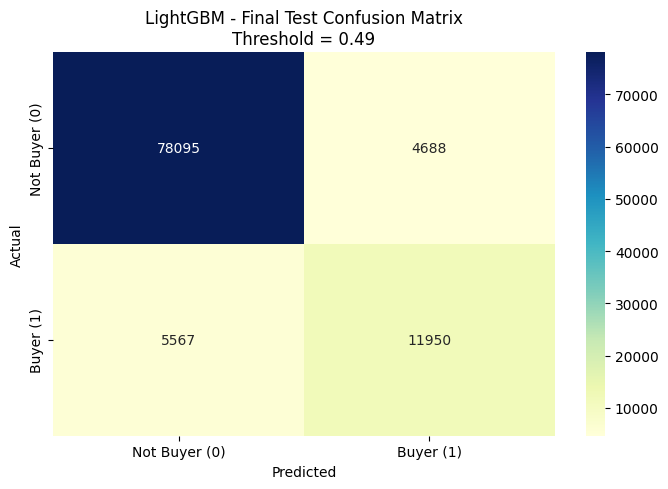


Confusion Matrix Breakdown:
True Negatives  (correct 0): 78,095
False Positives (0 -> 1)   : 4,688
False Negatives (1 -> 0)   : 5,567
True Positives  (correct 1): 11,950


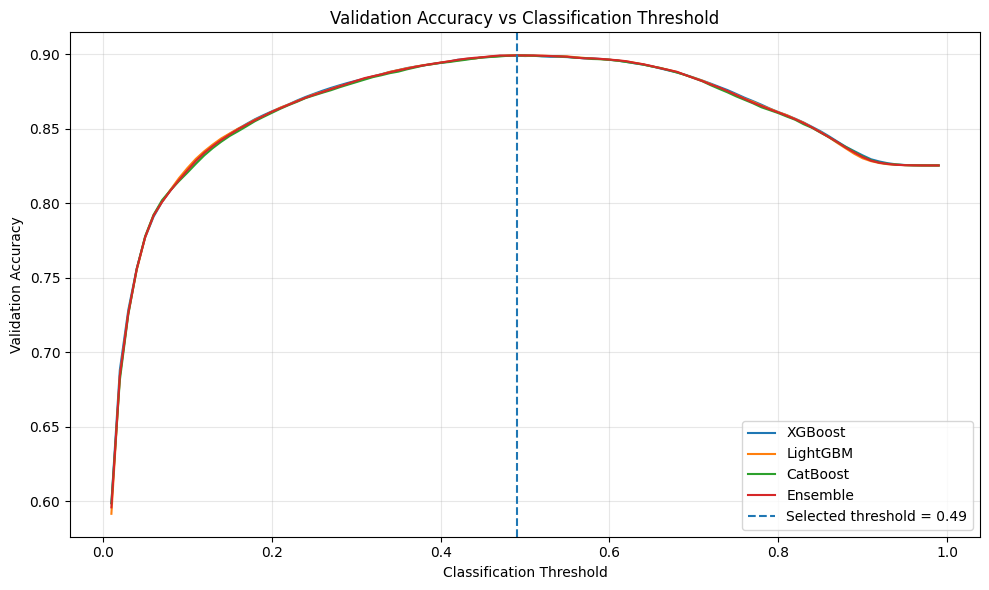

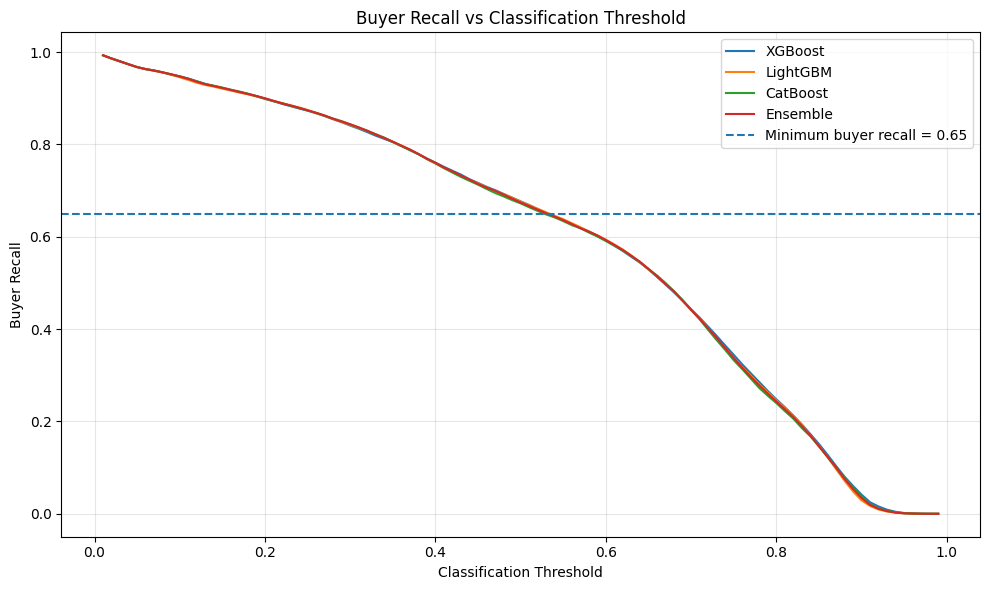


Top 20 XGBoost Features:
                    Feature  Importance
          Concern_x_Subsidy     0.64646
             Subsidy_Binary     0.14969
Environmental_Concern_Level     0.09636
      Range_Anxiety_Ordinal     0.02243
    Range_Anxiety_Level_Low     0.01768
       Subsidy_Available_No     0.01244
          Annual_Income_USD     0.01106
       Concern_x_HomeCharge     0.00846
          HomeCharge_Binary     0.00312
             Income_per_Car     0.00284
     HomeCharge_And_Subsidy     0.00227
           Daily_Commute_km     0.00216
   Range_Anxiety_Level_High     0.00210
       Number_of_Cars_Owned     0.00189
                        Age     0.00160
 Range_Anxiety_Level_Medium     0.00145
            City_Type_Urban     0.00139
       Commute_x_HomeCharge     0.00136
Charging_Stations_Near_Home     0.00125
         City_Type_Suburban     0.00118


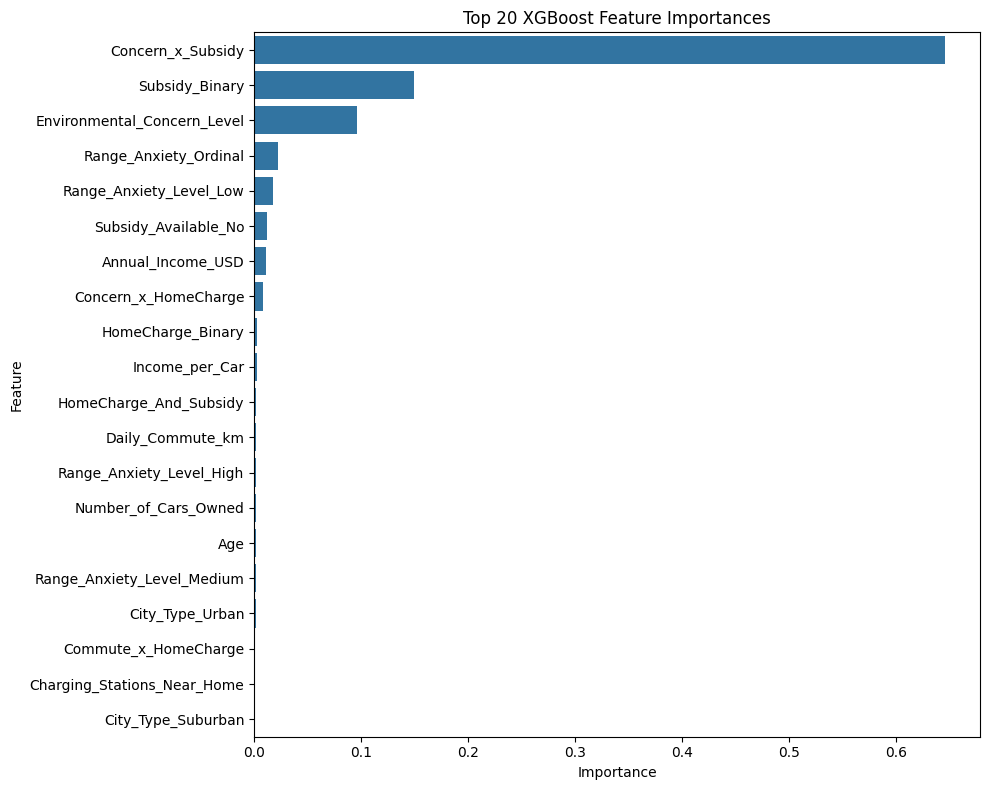

In [ ]:
# ============================================================
# EV PURCHASE PREDICTION - IMPROVED TRADITIONAL ML PIPELINE
# ============================================================

# If needed in Colab, uncomment this:
# !pip -q install xgboost lightgbm catboost

# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ============================================================
# 2. SETTINGS
# ============================================================

CSV_PATH = "/content/train.csv"

RANDOM_STATE = 42

# ------------------------------------------------------------
# IMPORTANT:
#
# If you want PURE maximum accuracy, use:
# MIN_BUYER_RECALL = None
#
# If you want high accuracy while requiring that at least
# 65% of actual buyers are detected, use:
# MIN_BUYER_RECALL = 0.65
#
# I recommend starting with 0.65.
# ------------------------------------------------------------

MIN_BUYER_RECALL = 0.65


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["Will_Buy_EV"].value_counts())
print("\nTarget percentages:")
print(df["Will_Buy_EV"].value_counts(normalize=True))


# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

def add_features(data):
    data = data.copy()

    # --------------------------------------------------------
    # Charging availability
    # --------------------------------------------------------

    data["Total_Charging_Stations"] = (
        data["Charging_Stations_Near_Home"] +
        data["Charging_Stations_Near_Work"]
    )

    # Charging availability relative to commute length
    data["Stations_per_Commute"] = (
        data["Total_Charging_Stations"] /
        (data["Daily_Commute_km"] + 1)
    )

    # Commute burden relative to available stations
    data["Commute_per_Station"] = (
        data["Daily_Commute_km"] /
        (data["Total_Charging_Stations"] + 1)
    )

    # --------------------------------------------------------
    # Income-related features
    # --------------------------------------------------------

    data["Income_per_Car"] = (
        data["Annual_Income_USD"] /
        (data["Number_of_Cars_Owned"] + 1)
    )

    # --------------------------------------------------------
    # Binary useful combinations
    # --------------------------------------------------------

    data["HomeCharge_Binary"] = (
        data["Home_Charging_Possible"]
        .map({"Yes": 1, "No": 0})
        .fillna(0)
    )

    data["Subsidy_Binary"] = (
        data["Subsidy_Available"]
        .map({"Yes": 1, "No": 0})
        .fillna(0)
    )

    # Has BOTH home charging and subsidy
    data["HomeCharge_And_Subsidy"] = (
        data["HomeCharge_Binary"] *
        data["Subsidy_Binary"]
    )

    # Environmental concern becomes more meaningful
    # when a subsidy is available
    data["Concern_x_Subsidy"] = (
        data["Environmental_Concern_Level"] *
        data["Subsidy_Binary"]
    )

    # Environmental concern + ability to charge at home
    data["Concern_x_HomeCharge"] = (
        data["Environmental_Concern_Level"] *
        data["HomeCharge_Binary"]
    )

    # Commute + home charging
    data["Commute_x_HomeCharge"] = (
        data["Daily_Commute_km"] *
        data["HomeCharge_Binary"]
    )

    # --------------------------------------------------------
    # Range anxiety is ORDINAL
    # Low < Medium < High
    # --------------------------------------------------------

    range_map = {
        "Low": 0,
        "Medium": 1,
        "High": 2
    }

    data["Range_Anxiety_Ordinal"] = (
        data["Range_Anxiety_Level"]
        .map(range_map)
        .fillna(-1)
    )

    return data


df = add_features(df)

print("\nShape after feature engineering:", df.shape)


# ============================================================
# 5. CREATE X AND y
# ============================================================

# Target
y = df["Will_Buy_EV"].map({
    "No": 0,
    "Yes": 1
}).astype(int)

# Drop target and ID
X = df.drop(
    columns=["Will_Buy_EV", "id"],
    errors="ignore"
)


# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
#
# 70% training
# 15% validation
# 15% final untouched test
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("\n================ DATA SPLIT ================")

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nPositive class percentages:")

print(
    "Train:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Validation:",
    round(y_val.mean() * 100, 2),
    "%"
)

print(
    "Test:",
    round(y_test.mean() * 100, 2),
    "%"
)


# ============================================================
# 7. IDENTIFY CATEGORICAL / NUMERIC COLUMNS
# ============================================================

categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

categorical_cols = [
    c for c in categorical_cols
    if c in X_train.columns
]

numeric_cols = [
    c for c in X_train.columns
    if c not in categorical_cols
]


# ============================================================
# 8. HANDLE MISSING VALUES
#
# Medians are learned ONLY from training data.
# ============================================================

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for col in numeric_cols:

    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)


for col in categorical_cols:

    X_train[col] = (
        X_train[col]
        .fillna("Missing")
        .astype(str)
    )

    X_val[col] = (
        X_val[col]
        .fillna("Missing")
        .astype(str)
    )

    X_test[col] = (
        X_test[col]
        .fillna("Missing")
        .astype(str)
    )


# ============================================================
# 9. ONE-HOT DATA FOR XGBOOST + LIGHTGBM
#
# IMPORTANT:
# NO StandardScaler.
# Tree models do not need it.
# ============================================================

X_train_enc = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_val_enc = pd.get_dummies(
    X_val,
    columns=categorical_cols,
    drop_first=False
)

X_test_enc = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)


# Make validation/test columns exactly match training
X_val_enc = X_val_enc.reindex(
    columns=X_train_enc.columns,
    fill_value=0
)

X_test_enc = X_test_enc.reindex(
    columns=X_train_enc.columns,
    fill_value=0
)

print("\nEncoded feature count:", X_train_enc.shape[1])


# ============================================================
# 10. TRAIN XGBOOST
# ============================================================

print("\n============================================")
print("TRAINING XGBOOST")
print("============================================")

xgb_model = XGBClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.05,

    min_child_weight=3,
    gamma=0.05,

    subsample=0.90,
    colsample_bytree=0.90,

    reg_alpha=0.05,
    reg_lambda=2.0,

    objective="binary:logistic",
    eval_metric="logloss",

    tree_method="hist",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_enc,
    y_train
)

xgb_val_probs = xgb_model.predict_proba(
    X_val_enc
)[:, 1]


# ============================================================
# 11. TRAIN LIGHTGBM
# ============================================================

print("\n============================================")
print("TRAINING LIGHTGBM")
print("============================================")

lgb_model = LGBMClassifier(
    n_estimators=700,

    learning_rate=0.04,

    num_leaves=31,
    max_depth=-1,

    min_child_samples=30,

    subsample=0.90,
    colsample_bytree=0.90,

    reg_alpha=0.05,
    reg_lambda=2.0,

    objective="binary",

    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_enc,
    y_train
)

lgb_val_probs = lgb_model.predict_proba(
    X_val_enc
)[:, 1]


# ============================================================
# 12. TRAIN CATBOOST USING NATIVE CATEGORIES
#
# This is different from your old notebook.
# CatBoost gets categorical columns directly.
# ============================================================

print("\n============================================")
print("TRAINING CATBOOST")
print("============================================")

cat_model = CatBoostClassifier(
    iterations=800,

    depth=7,
    learning_rate=0.05,

    loss_function="Logloss",
    eval_metric="AUC",

    l2_leaf_reg=5,

    random_seed=RANDOM_STATE,

    verbose=100,

    allow_writing_files=False
)

cat_model.fit(
    X_train,
    y_train,

    cat_features=categorical_cols,

    eval_set=(X_val, y_val),

    early_stopping_rounds=100,

    verbose=100
)

cat_val_probs = cat_model.predict_proba(
    X_val
)[:, 1]


# ============================================================
# 13. CREATE SIMPLE PROBABILITY ENSEMBLE
# ============================================================

ensemble_val_probs = (
    xgb_val_probs +
    lgb_val_probs +
    cat_val_probs
) / 3


# ============================================================
# 14. FUNCTION TO FIND BEST SINGLE THRESHOLD
# ============================================================

def find_best_threshold(
    y_true,
    probabilities,
    min_buyer_recall=None
):

    results = []

    # Search thresholds from 0.01 -> 0.99
    for threshold in np.arange(
        0.01,
        1.00,
        0.01
    ):

        pred = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "threshold": threshold,

            "accuracy":
                accuracy_score(
                    y_true,
                    pred
                ),

            "precision_1":
                precision_score(
                    y_true,
                    pred,
                    zero_division=0
                ),

            "recall_1":
                recall_score(
                    y_true,
                    pred,
                    zero_division=0
                ),

            "f1_1":
                f1_score(
                    y_true,
                    pred,
                    zero_division=0
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    pred
                )
        })

    result_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Option A:
    # maximize pure accuracy
    # --------------------------------------------------------

    if min_buyer_recall is None:

        best = result_df.loc[
            result_df["accuracy"].idxmax()
        ]

    # --------------------------------------------------------
    # Option B:
    # maximize accuracy while requiring buyer recall
    # --------------------------------------------------------

    else:

        eligible = result_df[
            result_df["recall_1"]
            >= min_buyer_recall
        ]

        if len(eligible) == 0:

            print(
                "\nWARNING:"
                " No threshold reached required recall."
            )

            best = result_df.loc[
                result_df["f1_1"].idxmax()
            ]

        else:

            best = eligible.loc[
                eligible["accuracy"].idxmax()
            ]

    return best, result_df


# ============================================================
# 15. FIND BEST THRESHOLD FOR EACH MODEL
#
# ONLY VALIDATION DATA IS USED HERE.
# ============================================================

validation_probabilities = {
    "XGBoost": xgb_val_probs,
    "LightGBM": lgb_val_probs,
    "CatBoost": cat_val_probs,
    "Ensemble": ensemble_val_probs
}


validation_results = {}
threshold_tables = {}

print("\n")
print("=" * 75)
print("VALIDATION MODEL COMPARISON")
print("=" * 75)


for model_name, probs in validation_probabilities.items():

    best, table = find_best_threshold(
        y_val,
        probs,
        min_buyer_recall=MIN_BUYER_RECALL
    )

    validation_results[model_name] = best
    threshold_tables[model_name] = table

    print(
        f"\n{model_name}"
    )

    print(
        f"Best threshold : "
        f"{best['threshold']:.2f}"
    )

    print(
        f"Accuracy       : "
        f"{best['accuracy']:.4f}"
    )

    print(
        f"Buyer Precision: "
        f"{best['precision_1']:.4f}"
    )

    print(
        f"Buyer Recall   : "
        f"{best['recall_1']:.4f}"
    )

    print(
        f"Buyer F1       : "
        f"{best['f1_1']:.4f}"
    )

    print(
        f"Balanced Acc   : "
        f"{best['balanced_accuracy']:.4f}"
    )

    print(
        f"ROC-AUC        : "
        f"{roc_auc_score(y_val, probs):.4f}"
    )

    print(
        f"PR-AUC         : "
        f"{average_precision_score(y_val, probs):.4f}"
    )


# ============================================================
# 16. CREATE COMPARISON TABLE
# ============================================================

comparison_rows = []

for name, best in validation_results.items():

    comparison_rows.append({
        "Model": name,
        "Threshold": best["threshold"],
        "Accuracy": best["accuracy"],
        "Buyer Precision": best["precision_1"],
        "Buyer Recall": best["recall_1"],
        "Buyer F1": best["f1_1"],
        "Balanced Accuracy": best["balanced_accuracy"],
        "ROC AUC":
            roc_auc_score(
                y_val,
                validation_probabilities[name]
            ),
        "PR AUC":
            average_precision_score(
                y_val,
                validation_probabilities[name]
            )
    })

comparison_df = pd.DataFrame(
    comparison_rows
).sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("=" * 75)
print("VALIDATION COMPARISON TABLE")
print("=" * 75)

print(
    comparison_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 17. SELECT BEST MODEL
#
# Highest validation accuracy among models satisfying
# our recall requirement.
# ============================================================

best_model_name = comparison_df.iloc[0]["Model"]

best_threshold = float(
    comparison_df.iloc[0]["Threshold"]
)

print("\n")
print("=" * 75)
print("SELECTED MODEL")
print("=" * 75)

print(
    "Selected model:",
    best_model_name
)

print(
    "Selected threshold:",
    round(best_threshold, 4)
)


# ============================================================
# 18. GET TEST PROBABILITIES
#
# Notice:
# We did NOT use y_test to choose model or threshold.
# ============================================================

if best_model_name == "XGBoost":

    test_probs = xgb_model.predict_proba(
        X_test_enc
    )[:, 1]


elif best_model_name == "LightGBM":

    test_probs = lgb_model.predict_proba(
        X_test_enc
    )[:, 1]


elif best_model_name == "CatBoost":

    test_probs = cat_model.predict_proba(
        X_test
    )[:, 1]


elif best_model_name == "Ensemble":

    xgb_test_probs = xgb_model.predict_proba(
        X_test_enc
    )[:, 1]

    lgb_test_probs = lgb_model.predict_proba(
        X_test_enc
    )[:, 1]

    cat_test_probs = cat_model.predict_proba(
        X_test
    )[:, 1]

    test_probs = (
        xgb_test_probs +
        lgb_test_probs +
        cat_test_probs
    ) / 3


# ============================================================
# 19. FINAL TEST PREDICTIONS
#
# ONE threshold.
# EVERY row gets class 0 or 1.
# ============================================================

final_predictions = (
    test_probs >= best_threshold
).astype(int)


# ============================================================
# 20. FINAL TEST METRICS
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_bal_acc = balanced_accuracy_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    test_probs
)

final_pr_auc = average_precision_score(
    y_test,
    test_probs
)


print("\n")
print("=" * 75)
print("FINAL UNTOUCHED TEST RESULTS")
print("=" * 75)

print(
    f"Model             : {best_model_name}"
)

print(
    f"Threshold         : {best_threshold:.2f}"
)

print(
    f"Accuracy          : {final_accuracy:.4f}"
)

print(
    f"Buyer Precision   : {final_precision:.4f}"
)

print(
    f"Buyer Recall      : {final_recall:.4f}"
)

print(
    f"Buyer F1          : {final_f1:.4f}"
)

print(
    f"Balanced Accuracy : {final_bal_acc:.4f}"
)

print(
    f"ROC-AUC           : {final_roc_auc:.4f}"
)

print(
    f"PR-AUC            : {final_pr_auc:.4f}"
)


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ]
    )
)


# ============================================================
# 21. FINAL CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],
    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ]
)

plt.title(
    f"{best_model_name} - Final Test Confusion Matrix\n"
    f"Threshold = {best_threshold:.2f}"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. CONFUSION MATRIX VALUES
# ============================================================

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown:")

print(
    f"True Negatives  (correct 0): {tn:,}"
)

print(
    f"False Positives (0 -> 1)   : {fp:,}"
)

print(
    f"False Negatives (1 -> 0)   : {fn:,}"
)

print(
    f"True Positives  (correct 1): {tp:,}"
)


# ============================================================
# 23. PLOT VALIDATION ACCURACY VS THRESHOLD
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for name, table in threshold_tables.items():

    plt.plot(
        table["threshold"],
        table["accuracy"],
        label=name
    )

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_threshold:.2f}"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Validation Accuracy vs Classification Threshold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. PLOT BUYER RECALL VS THRESHOLD
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for name, table in threshold_tables.items():

    plt.plot(
        table["threshold"],
        table["recall_1"],
        label=name
    )

if MIN_BUYER_RECALL is not None:

    plt.axhline(
        MIN_BUYER_RECALL,
        linestyle="--",
        label=f"Minimum buyer recall = {MIN_BUYER_RECALL}"
    )

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Buyer Recall"
)

plt.title(
    "Buyer Recall vs Classification Threshold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 25. FEATURE IMPORTANCE - XGBOOST
# ============================================================

importance_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

print("\nTop 20 XGBoost Features:")
print(
    importance_df
    .round(5)
    .to_string(index=False)
)


plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 XGBoost Feature Importances"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ADVANCED ENSEMBLES
# WEIGHTED SOFT VOTING + STACKING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ============================================================
# 1. EXISTING VALIDATION PROBABILITIES
#
# These already exist from your previous cell:
#
# xgb_val_probs
# lgb_val_probs
# cat_val_probs
#
# ============================================================

equal_voting_val_probs = (
    xgb_val_probs +
    lgb_val_probs +
    cat_val_probs
) / 3


# ============================================================
# 2. OPTIMIZED WEIGHTED SOFT VOTING
#
# Search weights ONLY using validation data.
#
# Example:
# LGB = 0.5
# XGB = 0.3
# CAT = 0.2
#
# We require every model to contribute at least 10%.
# ============================================================

print("\n")
print("=" * 80)
print("SEARCHING BEST WEIGHTED SOFT VOTING ENSEMBLE")
print("=" * 80)

weight_search_results = []

weight_values = np.arange(
    0.10,
    0.81,
    0.05
)


for lgb_weight in weight_values:

    for xgb_weight in weight_values:

        cat_weight = (
            1.0 -
            lgb_weight -
            xgb_weight
        )

        # Every model must contribute at least 10%
        if cat_weight < 0.10:
            continue

        if cat_weight > 0.80:
            continue

        weighted_probs = (
            lgb_weight * lgb_val_probs +
            xgb_weight * xgb_val_probs +
            cat_weight * cat_val_probs
        )

        best_result, _ = find_best_threshold(
            y_val,
            weighted_probs,
            min_buyer_recall=MIN_BUYER_RECALL
        )

        weight_search_results.append({

            "LGB_Weight":
                lgb_weight,

            "XGB_Weight":
                xgb_weight,

            "CAT_Weight":
                cat_weight,

            "Threshold":
                best_result["threshold"],

            "Accuracy":
                best_result["accuracy"],

            "Buyer_Precision":
                best_result["precision_1"],

            "Buyer_Recall":
                best_result["recall_1"],

            "Buyer_F1":
                best_result["f1_1"],

            "Balanced_Accuracy":
                best_result["balanced_accuracy"],

            "ROC_AUC":
                roc_auc_score(
                    y_val,
                    weighted_probs
                ),

            "PR_AUC":
                average_precision_score(
                    y_val,
                    weighted_probs
                )
        })


weight_search_df = pd.DataFrame(
    weight_search_results
)


# Sort primarily by accuracy,
# then buyer F1,
# then PR-AUC
weight_search_df = weight_search_df.sort_values(
    by=[
        "Accuracy",
        "Buyer_F1",
        "PR_AUC"
    ],
    ascending=False
).reset_index(drop=True)


best_weight_row = weight_search_df.iloc[0]


BEST_LGB_WEIGHT = float(
    best_weight_row["LGB_Weight"]
)

BEST_XGB_WEIGHT = float(
    best_weight_row["XGB_Weight"]
)

BEST_CAT_WEIGHT = float(
    best_weight_row["CAT_Weight"]
)


weighted_voting_val_probs = (

    BEST_LGB_WEIGHT *
    lgb_val_probs

    +

    BEST_XGB_WEIGHT *
    xgb_val_probs

    +

    BEST_CAT_WEIGHT *
    cat_val_probs
)


print("\nBest weights:")

print(
    f"LightGBM : {BEST_LGB_WEIGHT:.2f}"
)

print(
    f"XGBoost  : {BEST_XGB_WEIGHT:.2f}"
)

print(
    f"CatBoost : {BEST_CAT_WEIGHT:.2f}"
)

print(
    f"Threshold: "
    f"{best_weight_row['Threshold']:.2f}"
)

print(
    f"Accuracy : "
    f"{best_weight_row['Accuracy']:.4f}"
)

print(
    f"Recall   : "
    f"{best_weight_row['Buyer_Recall']:.4f}"
)

print(
    f"F1       : "
    f"{best_weight_row['Buyer_F1']:.4f}"
)

print(
    f"PR-AUC   : "
    f"{best_weight_row['PR_AUC']:.4f}"
)


print("\nTop 10 weight combinations:\n")

print(
    weight_search_df
    .head(10)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 3. STACKING
#
# IMPORTANT:
#
# Do NOT simply train LogisticRegression using:
#
# [xgb_val_probs, lgb_val_probs, cat_val_probs]
#
# and y_val.
#
# That would make the validation set part of training.
#
# Instead we create OUT-OF-FOLD predictions from X_train.
# ============================================================

print("\n")
print("=" * 80)
print("CREATING OUT-OF-FOLD PREDICTIONS FOR STACKING")
print("=" * 80)


# 3 folds is a good starting point for this large dataset.
# Change to 5 if you want a more expensive experiment.
N_STACK_FOLDS = 3


skf = StratifiedKFold(
    n_splits=N_STACK_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Three columns:
#
# 0 = XGBoost probability
# 1 = LightGBM probability
# 2 = CatBoost probability

oof_stack_train = np.zeros(
    (
        len(X_train),
        3
    )
)


# ============================================================
# MODEL FACTORIES
#
# Same general hyperparameters as your final models.
# ============================================================

def create_xgb_model():

    return XGBClassifier(

        n_estimators=700,

        max_depth=5,

        learning_rate=0.05,

        min_child_weight=3,

        gamma=0.05,

        subsample=0.90,

        colsample_bytree=0.90,

        reg_alpha=0.05,

        reg_lambda=2.0,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        random_state=RANDOM_STATE,

        n_jobs=-1
    )


def create_lgb_model():

    return LGBMClassifier(

        n_estimators=700,

        learning_rate=0.04,

        num_leaves=31,

        max_depth=-1,

        min_child_samples=30,

        subsample=0.90,

        colsample_bytree=0.90,

        reg_alpha=0.05,

        reg_lambda=2.0,

        objective="binary",

        random_state=RANDOM_STATE,

        n_jobs=-1,

        verbosity=-1
    )


def create_cat_model():

    return CatBoostClassifier(

        iterations=800,

        depth=7,

        learning_rate=0.05,

        loss_function="Logloss",

        eval_metric="AUC",

        l2_leaf_reg=5,

        random_seed=RANDOM_STATE,

        verbose=0,

        allow_writing_files=False
    )


# ============================================================
# 4. GENERATE OOF TRAINING PREDICTIONS
# ============================================================

for fold, (
    train_idx,
    holdout_idx
) in enumerate(

    skf.split(
        X_train_enc,
        y_train
    ),

    start=1
):

    print(
        f"\nStacking fold "
        f"{fold}/{N_STACK_FOLDS}"
    )


    # --------------------------------------------------------
    # Fold data for XGBoost / LightGBM
    # --------------------------------------------------------

    X_fold_train_enc = (
        X_train_enc.iloc[train_idx]
    )

    X_fold_holdout_enc = (
        X_train_enc.iloc[holdout_idx]
    )


    # --------------------------------------------------------
    # Raw data for CatBoost
    # --------------------------------------------------------

    X_fold_train_raw = (
        X_train.iloc[train_idx]
    )

    X_fold_holdout_raw = (
        X_train.iloc[holdout_idx]
    )


    y_fold_train = (
        y_train.iloc[train_idx]
    )


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    fold_xgb = create_xgb_model()

    fold_xgb.fit(
        X_fold_train_enc,
        y_fold_train
    )

    oof_stack_train[
        holdout_idx,
        0
    ] = (

        fold_xgb.predict_proba(
            X_fold_holdout_enc
        )[:, 1]

    )


    # --------------------------------------------------------
    # LIGHTGBM
    # --------------------------------------------------------

    fold_lgb = create_lgb_model()

    fold_lgb.fit(
        X_fold_train_enc,
        y_fold_train
    )

    oof_stack_train[
        holdout_idx,
        1
    ] = (

        fold_lgb.predict_proba(
            X_fold_holdout_enc
        )[:, 1]

    )


    # --------------------------------------------------------
    # CATBOOST
    # --------------------------------------------------------

    fold_cat = create_cat_model()

    fold_cat.fit(

        X_fold_train_raw,

        y_fold_train,

        cat_features=categorical_cols,

        verbose=0
    )

    oof_stack_train[
        holdout_idx,
        2
    ] = (

        fold_cat.predict_proba(
            X_fold_holdout_raw
        )[:, 1]

    )


# ============================================================
# 5. TRAIN META MODEL
#
# Logistic Regression is usually an excellent meta-model
# because the base models already capture nonlinear effects.
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING STACKING META MODEL")
print("=" * 80)


stack_meta_model = LogisticRegression(

    C=1.0,

    max_iter=2000,

    random_state=RANDOM_STATE
)


stack_meta_model.fit(

    oof_stack_train,

    y_train
)


print("\nMeta-model coefficients:")

meta_coefficients = pd.DataFrame({

    "Base_Model": [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Coefficient":
        stack_meta_model.coef_[0]
})


print(
    meta_coefficients
    .round(5)
    .to_string(index=False)
)


# ============================================================
# 6. CREATE STACKING VALIDATION FEATURES
#
# The base models from your existing pipeline were trained
# on X_train.
# ============================================================

stack_val_features = np.column_stack([

    xgb_val_probs,

    lgb_val_probs,

    cat_val_probs

])


stacking_val_probs = (

    stack_meta_model.predict_proba(
        stack_val_features
    )[:, 1]

)


# ============================================================
# 7. ADD NEW ENSEMBLES TO VALIDATION COMPARISON
# ============================================================

advanced_validation_probs = {

    # Individual best models
    "LightGBM":
        lgb_val_probs,

    "XGBoost":
        xgb_val_probs,

    "CatBoost":
        cat_val_probs,

    # Your existing simple ensemble
    "Equal Soft Voting":
        equal_voting_val_probs,

    # New ensembles
    "Weighted Soft Voting":
        weighted_voting_val_probs,

    "Stacking":
        stacking_val_probs
}


advanced_results = {}

advanced_threshold_tables = {}


print("\n")
print("=" * 80)
print("ADVANCED ENSEMBLE VALIDATION COMPARISON")
print("=" * 80)


for model_name, probs in (
    advanced_validation_probs.items()
):

    best_result, threshold_table = (
        find_best_threshold(

            y_val,

            probs,

            min_buyer_recall=
                MIN_BUYER_RECALL
        )
    )


    advanced_results[
        model_name
    ] = best_result


    advanced_threshold_tables[
        model_name
    ] = threshold_table


# ============================================================
# 8. CREATE FINAL VALIDATION TABLE
# ============================================================

advanced_rows = []


for name, best in advanced_results.items():

    probs = advanced_validation_probs[name]

    advanced_rows.append({

        "Model":
            name,

        "Threshold":
            best["threshold"],

        "Accuracy":
            best["accuracy"],

        "Buyer Precision":
            best["precision_1"],

        "Buyer Recall":
            best["recall_1"],

        "Buyer F1":
            best["f1_1"],

        "Balanced Accuracy":
            best["balanced_accuracy"],

        "ROC AUC":
            roc_auc_score(
                y_val,
                probs
            ),

        "PR AUC":
            average_precision_score(
                y_val,
                probs
            )
    })


advanced_comparison_df = (

    pd.DataFrame(
        advanced_rows
    )

    .sort_values(

        by=[
            "Accuracy",
            "Buyer F1",
            "PR AUC"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n")

print(
    advanced_comparison_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. SELECT WINNER USING VALIDATION ONLY
# ============================================================

advanced_best_model = (

    advanced_comparison_df
    .iloc[0]["Model"]

)


advanced_best_threshold = float(

    advanced_comparison_df
    .iloc[0]["Threshold"]

)


print("\n")
print("=" * 80)
print("BEST MODEL AFTER ENSEMBLE EXPERIMENT")
print("=" * 80)

print(
    "Selected model:",
    advanced_best_model
)

print(
    "Selected threshold:",
    round(
        advanced_best_threshold,
        4
    )
)


# ============================================================
# 10. NOW GET TEST PROBABILITIES
#
# Model/threshold selection is already finished.
# ============================================================

xgb_test_probs_advanced = (

    xgb_model.predict_proba(
        X_test_enc
    )[:, 1]

)


lgb_test_probs_advanced = (

    lgb_model.predict_proba(
        X_test_enc
    )[:, 1]

)


cat_test_probs_advanced = (

    cat_model.predict_proba(
        X_test
    )[:, 1]

)


# ------------------------------------------------------------
# Equal voting test probabilities
# ------------------------------------------------------------

equal_voting_test_probs = (

    xgb_test_probs_advanced +

    lgb_test_probs_advanced +

    cat_test_probs_advanced

) / 3


# ------------------------------------------------------------
# Weighted voting test probabilities
# ------------------------------------------------------------

weighted_voting_test_probs = (

    BEST_LGB_WEIGHT *
    lgb_test_probs_advanced

    +

    BEST_XGB_WEIGHT *
    xgb_test_probs_advanced

    +

    BEST_CAT_WEIGHT *
    cat_test_probs_advanced
)


# ------------------------------------------------------------
# Stacking test probabilities
# ------------------------------------------------------------

stack_test_features = np.column_stack([

    xgb_test_probs_advanced,

    lgb_test_probs_advanced,

    cat_test_probs_advanced

])


stacking_test_probs = (

    stack_meta_model.predict_proba(
        stack_test_features
    )[:, 1]

)


# ============================================================
# 11. GET PROBABILITIES OF SELECTED MODEL
# ============================================================

test_probability_map = {

    "LightGBM":
        lgb_test_probs_advanced,

    "XGBoost":
        xgb_test_probs_advanced,

    "CatBoost":
        cat_test_probs_advanced,

    "Equal Soft Voting":
        equal_voting_test_probs,

    "Weighted Soft Voting":
        weighted_voting_test_probs,

    "Stacking":
        stacking_test_probs
}


advanced_test_probs = (

    test_probability_map[
        advanced_best_model
    ]

)


advanced_test_predictions = (

    advanced_test_probs
    >=
    advanced_best_threshold

).astype(int)


# ============================================================
# 12. FINAL TEST RESULTS
# ============================================================

adv_accuracy = accuracy_score(
    y_test,
    advanced_test_predictions
)

adv_precision = precision_score(
    y_test,
    advanced_test_predictions,
    zero_division=0
)

adv_recall = recall_score(
    y_test,
    advanced_test_predictions,
    zero_division=0
)

adv_f1 = f1_score(
    y_test,
    advanced_test_predictions,
    zero_division=0
)

adv_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        advanced_test_predictions
    )
)

adv_roc_auc = roc_auc_score(
    y_test,
    advanced_test_probs
)

adv_pr_auc = average_precision_score(
    y_test,
    advanced_test_probs
)


print("\n")
print("=" * 80)
print("FINAL ADVANCED ENSEMBLE TEST RESULTS")
print("=" * 80)

print(
    f"Model             : "
    f"{advanced_best_model}"
)

print(
    f"Threshold         : "
    f"{advanced_best_threshold:.2f}"
)

print(
    f"Accuracy          : "
    f"{adv_accuracy:.4f}"
)

print(
    f"Buyer Precision   : "
    f"{adv_precision:.4f}"
)

print(
    f"Buyer Recall      : "
    f"{adv_recall:.4f}"
)

print(
    f"Buyer F1          : "
    f"{adv_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{adv_balanced_accuracy:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{adv_roc_auc:.4f}"
)

print(
    f"PR-AUC            : "
    f"{adv_pr_auc:.4f}"
)


print("\nClassification Report:\n")

print(
    classification_report(

        y_test,

        advanced_test_predictions,

        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ]
    )
)


# ============================================================
# 13. CONFUSION MATRIX VALUES
# ============================================================

advanced_cm = confusion_matrix(
    y_test,
    advanced_test_predictions
)

tn, fp, fn, tp = (
    advanced_cm.ravel()
)


print("\nConfusion Matrix:")

print(
    advanced_cm
)

print(
    f"\nTrue Negatives : {tn:,}"
)

print(
    f"False Positives: {fp:,}"
)

print(
    f"False Negatives: {fn:,}"
)

print(
    f"True Positives : {tp:,}"
)


# ============================================================
# 14. COMPARE OLD LIGHTGBM VS NEW WINNER
# ============================================================

print("\n")
print("=" * 80)
print("OLD LIGHTGBM VS ADVANCED ENSEMBLE")
print("=" * 80)


comparison_final = pd.DataFrame({

    "Model": [
        "Previous LightGBM",
        advanced_best_model
    ],

    "Accuracy": [
        final_accuracy,
        adv_accuracy
    ],

    "Buyer Precision": [
        final_precision,
        adv_precision
    ],

    "Buyer Recall": [
        final_recall,
        adv_recall
    ],

    "Buyer F1": [
        final_f1,
        adv_f1
    ],

    "ROC AUC": [
        final_roc_auc,
        adv_roc_auc
    ],

    "PR AUC": [
        final_pr_auc,
        adv_pr_auc
    ]
})


print(
    comparison_final
    .round(4)
    .to_string(index=False)
)



SEARCHING BEST WEIGHTED SOFT VOTING ENSEMBLE

Best weights:
LightGBM : 0.70
XGBoost  : 0.15
CatBoost : 0.15
Threshold: 0.48
Accuracy : 0.8995
Recall   : 0.6925
F1       : 0.7064
PR-AUC   : 0.7582

Top 10 weight combinations:

 LGB_Weight  XGB_Weight  CAT_Weight  Threshold  Accuracy  Buyer_Precision  Buyer_Recall  Buyer_F1  Balanced_Accuracy  ROC_AUC  PR_AUC
       0.70        0.15        0.15       0.48    0.8995           0.7209        0.6925    0.7064             0.8179   0.9419  0.7582
       0.70        0.10        0.20       0.48    0.8995           0.7210        0.6921    0.7062             0.8177   0.9419  0.7582
       0.65        0.15        0.20       0.48    0.8994           0.7208        0.6921    0.7062             0.8177   0.9419  0.7582
       0.65        0.10        0.25       0.48    0.8994           0.7209        0.6918    0.7061             0.8176   0.9419  0.7582
       0.60        0.15        0.25       0.48    0.8994           0.7208        0.6918    0.7060     

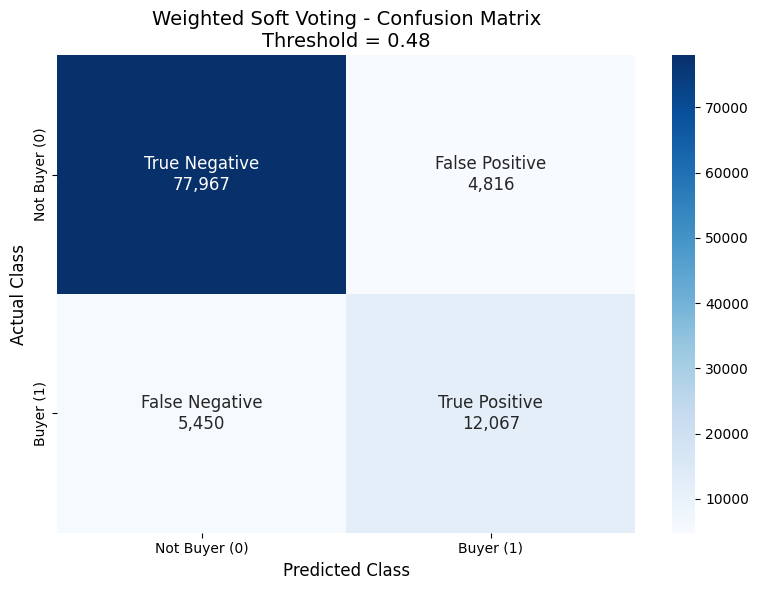

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_test,
    advanced_test_predictions
)

tn, fp, fn, tp = cm.ravel()


labels = np.array([
    [
        f"True Negative\n{tn:,}",
        f"False Positive\n{fp:,}"
    ],
    [
        f"False Negative\n{fn:,}",
        f"True Positive\n{tp:,}"
    ]
])


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],
    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],
    annot_kws={
        "size": 12
    }
)

plt.title(
    f"{advanced_best_model} - Confusion Matrix\n"
    f"Threshold = {advanced_best_threshold:.2f}",
    fontsize=14
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.tight_layout()
plt.show()

CLASS DISTRIBUTION BEFORE SMOTE
Not Buyer (0): 386,320
Buyer (1)    : 81,745

Buyer percentage: 17.46%


CLASS DISTRIBUTION AFTER SMOTE
Not Buyer (0): 386,320
Buyer (1)    : 386,320

Buyer percentage: 50.00%

Original training shape: (468065, 35)
SMOTE training shape   : (772640, 35)


TRAINING LIGHTGBM + SMOTE


LIGHTGBM + SMOTE VALIDATION RESULTS
Best threshold     : 0.51
Accuracy           : 0.8991
Buyer Precision    : 0.7235
Buyer Recall       : 0.6837
Buyer F1           : 0.7030
Balanced Accuracy  : 0.8142
ROC-AUC            : 0.9415
PR-AUC             : 0.7552


FINAL LIGHTGBM + SMOTE TEST RESULTS
Threshold          : 0.51
Accuracy           : 0.8972
Buyer Precision    : 0.7171
Buyer Recall       : 0.6793
Buyer F1           : 0.6977
Balanced Accuracy  : 0.8113
ROC-AUC            : 0.9411
PR-AUC             : 0.7515

Classification Report:

               precision    recall  f1-score   support

Not Buyer (0)     0.9329    0.9433    0.9381     82783
    Buyer (1)     0.7171    0.6

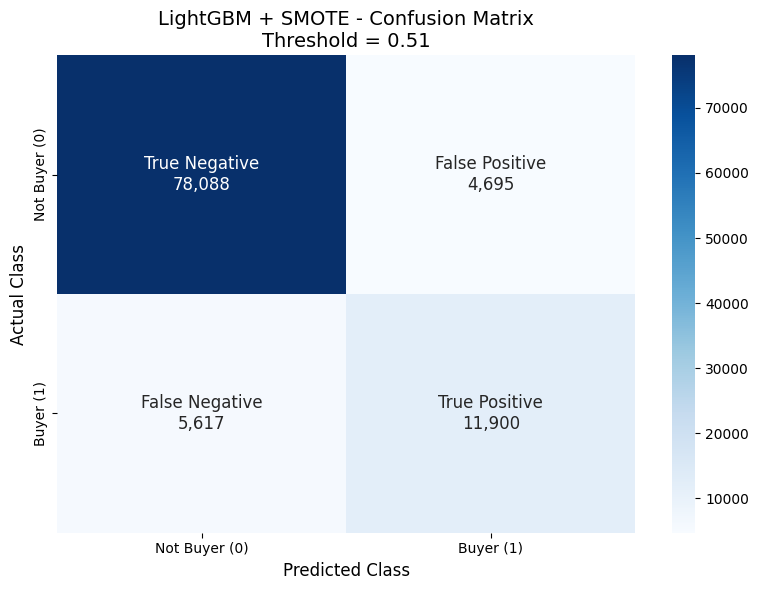



CONFUSION MATRIX BREAKDOWN
True Negatives  : 78,088
False Positives : 4,695
False Negatives : 5,617
True Positives  : 11,900


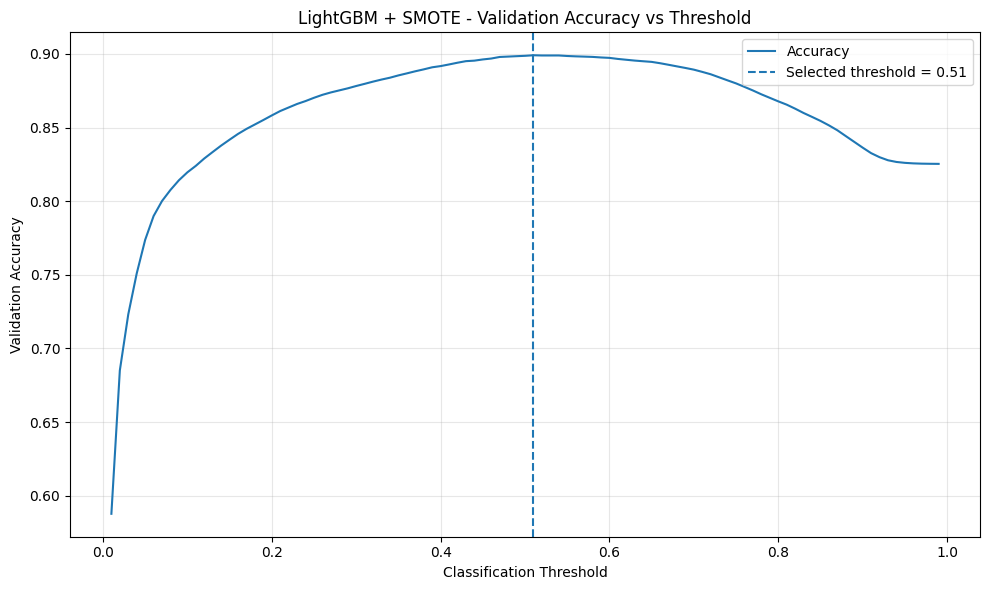

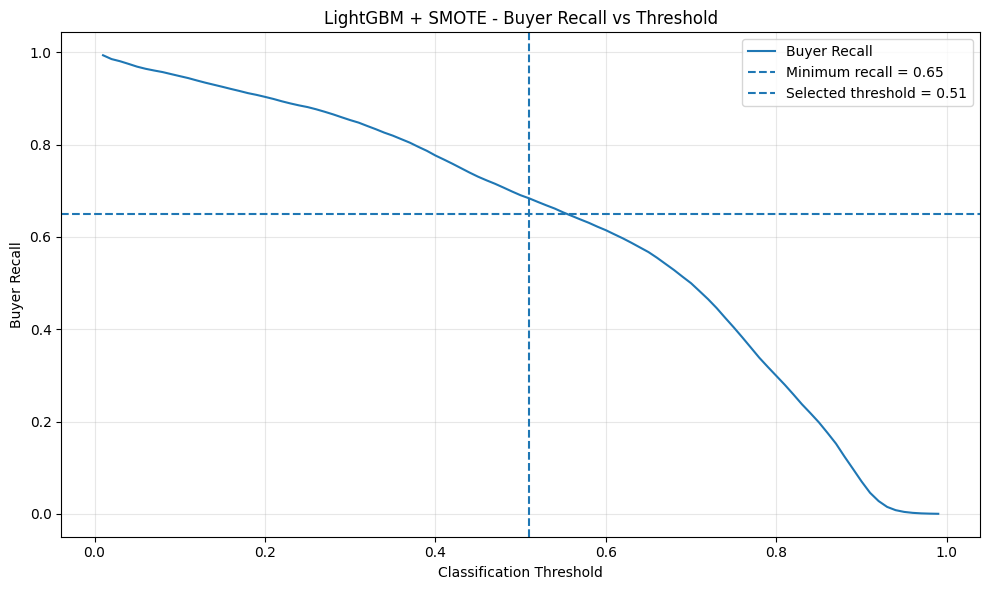


Top 20 LightGBM + SMOTE Features:

                    Feature  Importance
          Annual_Income_USD        3988
             Income_per_Car        1875
                        Age        1609
           Daily_Commute_km        1564
       Stations_per_Commute        1345
        Commute_per_Station        1249
          Concern_x_Subsidy        1193
Environmental_Concern_Level         913
Charging_Stations_Near_Work         833
       Commute_x_HomeCharge         800
Charging_Stations_Near_Home         775
    Total_Charging_Stations         578
       Concern_x_HomeCharge         438
 Current_Car_Type_Hatchback         399
     Current_Car_Type_Sedan         392
       Current_Car_Type_SUV         376
     Current_Car_Type_Truck         316
      Range_Anxiety_Ordinal         314
            City_Type_Rural         293
         City_Type_Suburban         284


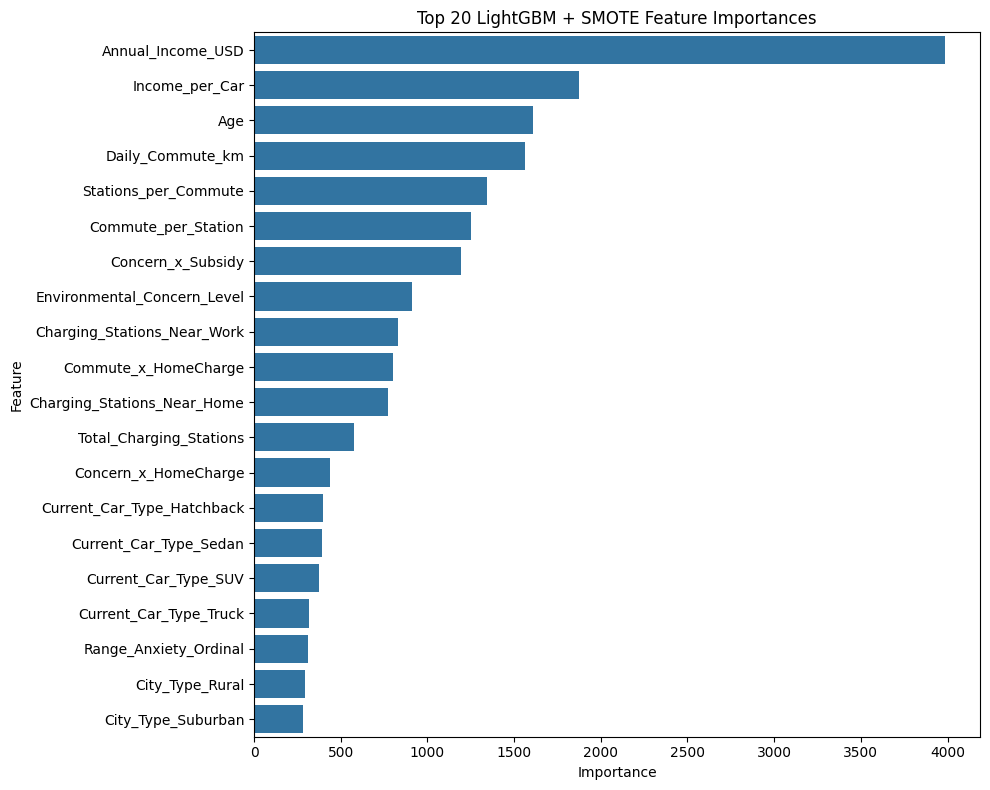



ORIGINAL LIGHTGBM VS LIGHTGBM + SMOTE
            Model  Accuracy  Buyer Precision  Buyer Recall  Buyer F1  Balanced Accuracy  ROC AUC  PR AUC
Original LightGBM    0.8978           0.7182        0.6822    0.6998             0.8128   0.9415  0.7539
 LightGBM + SMOTE    0.8972           0.7171        0.6793    0.6977             0.8113   0.9411  0.7515


In [ ]:
# ============================================================
# LIGHTGBM + SMOTE
#
# Uses your existing:
#     X_train_enc
#     X_val_enc
#     X_test_enc
#     y_train
#     y_val
#     y_test
#
# SMOTE is applied ONLY to training data.
# Validation and test data remain untouched.
# ============================================================


# If imbalanced-learn is not installed:
# !pip install -q imbalanced-learn


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. SETTINGS
# ============================================================

RANDOM_STATE = 42

# Same requirement as your previous model:
# Buyer recall must be at least 65%
MIN_BUYER_RECALL = 0.65


# 1.0 means:
# minority class will be oversampled until
# Yes and No have equal numbers.
SMOTE_RATIO = 1.0


# ============================================================
# 3. CHECK CLASS DISTRIBUTION BEFORE SMOTE
# ============================================================

print("=" * 75)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("=" * 75)

before_counts = y_train.value_counts().sort_index()

print(
    f"Not Buyer (0): "
    f"{before_counts.get(0, 0):,}"
)

print(
    f"Buyer (1)    : "
    f"{before_counts.get(1, 0):,}"
)

print(
    f"\nBuyer percentage: "
    f"{y_train.mean() * 100:.2f}%"
)


# ============================================================
# 4. APPLY SMOTE
#
# IMPORTANT:
#
# Only training data gets SMOTE.
#
# DO NOT SMOTE:
#     X_val_enc
#     X_test_enc
#
# ============================================================

smote = SMOTE(
    sampling_strategy=SMOTE_RATIO,
    random_state=RANDOM_STATE,
    k_neighbors=5
)


X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_enc,
        y_train
    )
)


# Convert back to DataFrame in case SMOTE
# returns an array depending on package version

if not isinstance(
    X_train_smote,
    pd.DataFrame
):

    X_train_smote = pd.DataFrame(
        X_train_smote,
        columns=X_train_enc.columns
    )


if not isinstance(
    y_train_smote,
    pd.Series
):

    y_train_smote = pd.Series(
        y_train_smote,
        name=y_train.name
    )


# ============================================================
# 5. CHECK CLASS DISTRIBUTION AFTER SMOTE
# ============================================================

print("\n")
print("=" * 75)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("=" * 75)

after_counts = (
    y_train_smote
    .value_counts()
    .sort_index()
)


print(
    f"Not Buyer (0): "
    f"{after_counts.get(0, 0):,}"
)

print(
    f"Buyer (1)    : "
    f"{after_counts.get(1, 0):,}"
)

print(
    f"\nBuyer percentage: "
    f"{y_train_smote.mean() * 100:.2f}%"
)


print(
    "\nOriginal training shape:",
    X_train_enc.shape
)

print(
    "SMOTE training shape   :",
    X_train_smote.shape
)


# ============================================================
# 6. TRAIN LIGHTGBM ON SMOTE DATA
#
# Same parameters as your current best LightGBM.
# ============================================================

print("\n")
print("=" * 75)
print("TRAINING LIGHTGBM + SMOTE")
print("=" * 75)


lgb_smote_model = LGBMClassifier(

    n_estimators=700,

    learning_rate=0.04,

    num_leaves=31,

    max_depth=-1,

    min_child_samples=30,

    subsample=0.90,

    colsample_bytree=0.90,

    reg_alpha=0.05,

    reg_lambda=2.0,

    objective="binary",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbosity=-1
)


lgb_smote_model.fit(
    X_train_smote,
    y_train_smote
)


# ============================================================
# 7. VALIDATION PROBABILITIES
#
# Validation is ORIGINAL data.
# No SMOTE here.
# ============================================================

smote_val_probs = (
    lgb_smote_model.predict_proba(
        X_val_enc
    )[:, 1]
)


# ============================================================
# 8. FUNCTION TO SEARCH BEST THRESHOLD
#
# Same logic:
#
# maximize accuracy
# while buyer recall >= 65%
# ============================================================

def find_best_smote_threshold(
    y_true,
    probabilities,
    min_buyer_recall=0.65
):

    results = []


    for threshold in np.arange(
        0.01,
        1.00,
        0.01
    ):

        predictions = (
            probabilities >= threshold
        ).astype(int)


        results.append({

            "threshold":
                threshold,

            "accuracy":
                accuracy_score(
                    y_true,
                    predictions
                ),

            "precision_1":
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "recall_1":
                recall_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "f1_1":
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    predictions
                )
        })


    result_df = pd.DataFrame(
        results
    )


    # Only thresholds satisfying
    # our buyer recall requirement
    eligible = result_df[
        result_df["recall_1"]
        >= min_buyer_recall
    ]


    if len(eligible) > 0:

        # Highest accuracy first.
        #
        # If two thresholds have same accuracy,
        # prefer higher F1.
        eligible = eligible.sort_values(
            by=[
                "accuracy",
                "f1_1"
            ],
            ascending=False
        )

        best = eligible.iloc[0]

    else:

        print(
            "\nWARNING:"
            " No threshold achieved required "
            "buyer recall."
        )

        # Fallback: highest Buyer F1
        best = result_df.loc[
            result_df["f1_1"].idxmax()
        ]


    return best, result_df


# ============================================================
# 9. FIND BEST VALIDATION THRESHOLD
# ============================================================

smote_best, smote_threshold_table = (
    find_best_smote_threshold(

        y_val,

        smote_val_probs,

        min_buyer_recall=
            MIN_BUYER_RECALL
    )
)


SMOTE_BEST_THRESHOLD = float(
    smote_best["threshold"]
)


# ============================================================
# 10. VALIDATION RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("LIGHTGBM + SMOTE VALIDATION RESULTS")
print("=" * 75)


print(
    f"Best threshold     : "
    f"{SMOTE_BEST_THRESHOLD:.2f}"
)

print(
    f"Accuracy           : "
    f"{smote_best['accuracy']:.4f}"
)

print(
    f"Buyer Precision    : "
    f"{smote_best['precision_1']:.4f}"
)

print(
    f"Buyer Recall       : "
    f"{smote_best['recall_1']:.4f}"
)

print(
    f"Buyer F1           : "
    f"{smote_best['f1_1']:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{smote_best['balanced_accuracy']:.4f}"
)


smote_val_roc_auc = roc_auc_score(
    y_val,
    smote_val_probs
)

smote_val_pr_auc = (
    average_precision_score(
        y_val,
        smote_val_probs
    )
)


print(
    f"ROC-AUC            : "
    f"{smote_val_roc_auc:.4f}"
)

print(
    f"PR-AUC             : "
    f"{smote_val_pr_auc:.4f}"
)


# ============================================================
# 11. TEST PROBABILITIES
#
# We touch test only AFTER:
#
# 1. model trained
# 2. threshold selected on validation
# ============================================================

smote_test_probs = (
    lgb_smote_model.predict_proba(
        X_test_enc
    )[:, 1]
)


# ============================================================
# 12. FINAL YES / NO PREDICTIONS
# ============================================================

smote_test_predictions = (

    smote_test_probs
    >=
    SMOTE_BEST_THRESHOLD

).astype(int)


# Every row receives:
#
# 0 = No / Not Buyer
# 1 = Yes / Buyer


# ============================================================
# 13. FINAL TEST METRICS
# ============================================================

smote_test_accuracy = (
    accuracy_score(
        y_test,
        smote_test_predictions
    )
)


smote_test_precision = (
    precision_score(
        y_test,
        smote_test_predictions,
        zero_division=0
    )
)


smote_test_recall = (
    recall_score(
        y_test,
        smote_test_predictions,
        zero_division=0
    )
)


smote_test_f1 = (
    f1_score(
        y_test,
        smote_test_predictions,
        zero_division=0
    )
)


smote_test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        smote_test_predictions
    )
)


smote_test_roc_auc = (
    roc_auc_score(
        y_test,
        smote_test_probs
    )
)


smote_test_pr_auc = (
    average_precision_score(
        y_test,
        smote_test_probs
    )
)


# ============================================================
# 14. PRINT FINAL TEST RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("FINAL LIGHTGBM + SMOTE TEST RESULTS")
print("=" * 75)


print(
    f"Threshold          : "
    f"{SMOTE_BEST_THRESHOLD:.2f}"
)

print(
    f"Accuracy           : "
    f"{smote_test_accuracy:.4f}"
)

print(
    f"Buyer Precision    : "
    f"{smote_test_precision:.4f}"
)

print(
    f"Buyer Recall       : "
    f"{smote_test_recall:.4f}"
)

print(
    f"Buyer F1           : "
    f"{smote_test_f1:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{smote_test_balanced_accuracy:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{smote_test_roc_auc:.4f}"
)

print(
    f"PR-AUC             : "
    f"{smote_test_pr_auc:.4f}"
)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print(
    "\nClassification Report:\n"
)


print(
    classification_report(

        y_test,

        smote_test_predictions,

        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ],

        digits=4
    )
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

smote_cm = confusion_matrix(
    y_test,
    smote_test_predictions
)


tn, fp, fn, tp = (
    smote_cm.ravel()
)


labels = np.array([

    [
        f"True Negative\n{tn:,}",
        f"False Positive\n{fp:,}"
    ],

    [
        f"False Negative\n{fn:,}",
        f"True Positive\n{tp:,}"
    ]

])


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    smote_cm,

    annot=labels,

    fmt="",

    cmap="Blues",

    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)


plt.title(

    "LightGBM + SMOTE - Confusion Matrix\n"
    f"Threshold = "
    f"{SMOTE_BEST_THRESHOLD:.2f}",

    fontsize=14
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "Actual Class",
    fontsize=12
)


plt.tight_layout()
plt.show()


# ============================================================
# 17. CONFUSION MATRIX BREAKDOWN
# ============================================================

print("\n")
print("=" * 75)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 75)

print(
    f"True Negatives  : {tn:,}"
)

print(
    f"False Positives : {fp:,}"
)

print(
    f"False Negatives : {fn:,}"
)

print(
    f"True Positives  : {tp:,}"
)


# ============================================================
# 18. PLOT VALIDATION ACCURACY VS THRESHOLD
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    smote_threshold_table[
        "threshold"
    ],

    smote_threshold_table[
        "accuracy"
    ],

    label="Accuracy"
)


plt.axvline(

    SMOTE_BEST_THRESHOLD,

    linestyle="--",

    label=(
        f"Selected threshold = "
        f"{SMOTE_BEST_THRESHOLD:.2f}"
    )
)


plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "LightGBM + SMOTE - "
    "Validation Accuracy vs Threshold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 19. PLOT BUYER RECALL VS THRESHOLD
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    smote_threshold_table[
        "threshold"
    ],

    smote_threshold_table[
        "recall_1"
    ],

    label="Buyer Recall"
)


plt.axhline(

    MIN_BUYER_RECALL,

    linestyle="--",

    label=(
        f"Minimum recall = "
        f"{MIN_BUYER_RECALL:.2f}"
    )
)


plt.axvline(

    SMOTE_BEST_THRESHOLD,

    linestyle="--",

    label=(
        f"Selected threshold = "
        f"{SMOTE_BEST_THRESHOLD:.2f}"
    )
)


plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Buyer Recall"
)

plt.title(
    "LightGBM + SMOTE - "
    "Buyer Recall vs Threshold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

smote_importance_df = pd.DataFrame({

    "Feature":
        X_train_enc.columns,

    "Importance":
        lgb_smote_model.feature_importances_
})


smote_importance_df = (

    smote_importance_df

    .sort_values(
        "Importance",
        ascending=False
    )

    .head(20)
)


print("\nTop 20 LightGBM + SMOTE Features:\n")


print(

    smote_importance_df

    .to_string(
        index=False
    )
)


plt.figure(
    figsize=(10, 8)
)


sns.barplot(

    data=smote_importance_df,

    x="Importance",

    y="Feature"
)


plt.title(
    "Top 20 LightGBM + SMOTE "
    "Feature Importances"
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. OPTIONAL:
# COMPARE AGAINST YOUR PREVIOUS LIGHTGBM
#
# This section will run if your old model-result
# variables still exist in the notebook.
# ============================================================

if all(
    name in globals()
    for name in [
        "final_accuracy",
        "final_precision",
        "final_recall",
        "final_f1",
        "final_bal_acc",
        "final_roc_auc",
        "final_pr_auc"
    ]
):

    comparison_smote = pd.DataFrame({

        "Model": [
            "Original LightGBM",
            "LightGBM + SMOTE"
        ],

        "Accuracy": [
            final_accuracy,
            smote_test_accuracy
        ],

        "Buyer Precision": [
            final_precision,
            smote_test_precision
        ],

        "Buyer Recall": [
            final_recall,
            smote_test_recall
        ],

        "Buyer F1": [
            final_f1,
            smote_test_f1
        ],

        "Balanced Accuracy": [
            final_bal_acc,
            smote_test_balanced_accuracy
        ],

        "ROC AUC": [
            final_roc_auc,
            smote_test_roc_auc
        ],

        "PR AUC": [
            final_pr_auc,
            smote_test_pr_auc
        ]
    })


    print("\n")
    print("=" * 75)
    print("ORIGINAL LIGHTGBM VS LIGHTGBM + SMOTE")
    print("=" * 75)


    print(

        comparison_smote

        .round(4)

        .to_string(
            index=False
        )
    )

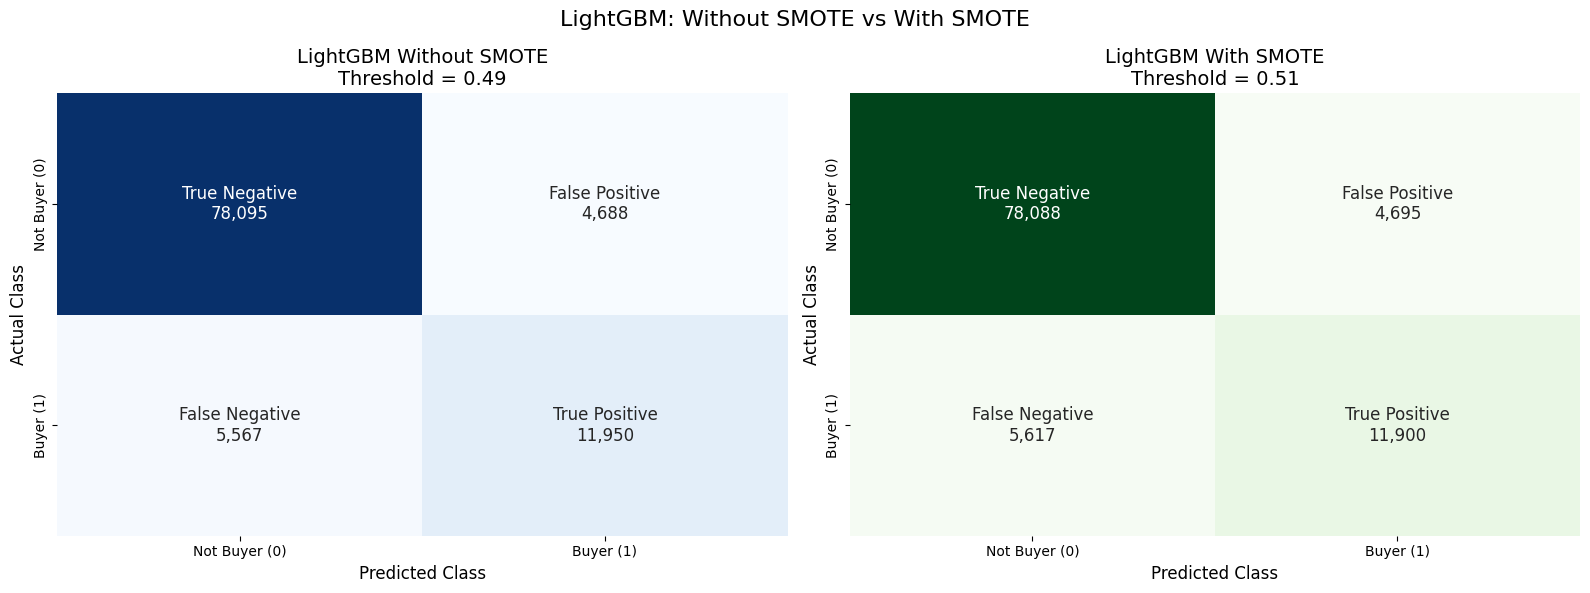



LIGHTGBM vs LIGHTGBM + SMOTE
           Model  Threshold  Accuracy  Buyer Precision  Buyer Recall  Buyer F1  Balanced Accuracy  ROC AUC  PR AUC
        LightGBM       0.49    0.8978           0.7182        0.6822    0.6998             0.8128   0.9415  0.7539
LightGBM + SMOTE       0.51    0.8972           0.7171        0.6793    0.6977             0.8113   0.9411  0.7515


WITHOUT SMOTE
True Negatives  : 78,095
False Positives : 4,688
False Negatives : 5,567
True Positives  : 11,950


WITH SMOTE
True Negatives  : 78,088
False Positives : 4,695
False Negatives : 5,617
True Positives  : 11,900


In [ ]:
# ============================================================
# LIGHTGBM vs LIGHTGBM + SMOTE
# CONFUSION MATRIX COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. ORIGINAL LIGHTGBM
# ============================================================

# Get threshold selected using validation data
lgb_threshold = float(
    validation_results["LightGBM"]["threshold"]
)

# Test probabilities
lgb_test_probs_compare = (
    lgb_model.predict_proba(
        X_test_enc
    )[:, 1]
)

# Test predictions
lgb_predictions_compare = (
    lgb_test_probs_compare >= lgb_threshold
).astype(int)


# ============================================================
# 2. LIGHTGBM + SMOTE
# ============================================================

# Threshold selected using validation data
smote_threshold = SMOTE_BEST_THRESHOLD

# Test probabilities
lgb_smote_test_probs_compare = (
    lgb_smote_model.predict_proba(
        X_test_enc
    )[:, 1]
)

# Test predictions
lgb_smote_predictions_compare = (
    lgb_smote_test_probs_compare
    >= smote_threshold
).astype(int)


# ============================================================
# 3. CONFUSION MATRICES
# ============================================================

cm_original = confusion_matrix(
    y_test,
    lgb_predictions_compare
)

cm_smote = confusion_matrix(
    y_test,
    lgb_smote_predictions_compare
)


# Extract individual values
tn1, fp1, fn1, tp1 = cm_original.ravel()

tn2, fp2, fn2, tp2 = cm_smote.ravel()


# ============================================================
# 4. CUSTOM LABELS
# ============================================================

labels_original = np.array([

    [
        f"True Negative\n{tn1:,}",
        f"False Positive\n{fp1:,}"
    ],

    [
        f"False Negative\n{fn1:,}",
        f"True Positive\n{tp1:,}"
    ]

])


labels_smote = np.array([

    [
        f"True Negative\n{tn2:,}",
        f"False Positive\n{fp2:,}"
    ],

    [
        f"False Negative\n{fn2:,}",
        f"True Positive\n{tp2:,}"
    ]

])


# ============================================================
# 5. PLOT BOTH MATRICES SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ------------------------------------------------------------
# ORIGINAL LIGHTGBM
# ------------------------------------------------------------

sns.heatmap(
    cm_original,
    annot=labels_original,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=axes[0],

    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)


axes[0].set_title(
    "LightGBM Without SMOTE\n"
    f"Threshold = {lgb_threshold:.2f}",
    fontsize=14
)

axes[0].set_xlabel(
    "Predicted Class",
    fontsize=12
)

axes[0].set_ylabel(
    "Actual Class",
    fontsize=12
)


# ------------------------------------------------------------
# LIGHTGBM + SMOTE
# ------------------------------------------------------------

sns.heatmap(
    cm_smote,
    annot=labels_smote,
    fmt="",
    cmap="Greens",
    cbar=False,
    ax=axes[1],

    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)


axes[1].set_title(
    "LightGBM With SMOTE\n"
    f"Threshold = {smote_threshold:.2f}",
    fontsize=14
)

axes[1].set_xlabel(
    "Predicted Class",
    fontsize=12
)

axes[1].set_ylabel(
    "Actual Class",
    fontsize=12
)


plt.suptitle(
    "LightGBM: Without SMOTE vs With SMOTE",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. CALCULATE METRICS
# ============================================================

original_metrics = {

    "Model":
        "LightGBM",

    "Threshold":
        lgb_threshold,

    "Accuracy":
        accuracy_score(
            y_test,
            lgb_predictions_compare
        ),

    "Buyer Precision":
        precision_score(
            y_test,
            lgb_predictions_compare,
            zero_division=0
        ),

    "Buyer Recall":
        recall_score(
            y_test,
            lgb_predictions_compare,
            zero_division=0
        ),

    "Buyer F1":
        f1_score(
            y_test,
            lgb_predictions_compare,
            zero_division=0
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_test,
            lgb_predictions_compare
        ),

    "ROC AUC":
        roc_auc_score(
            y_test,
            lgb_test_probs_compare
        ),

    "PR AUC":
        average_precision_score(
            y_test,
            lgb_test_probs_compare
        )
}


smote_metrics = {

    "Model":
        "LightGBM + SMOTE",

    "Threshold":
        smote_threshold,

    "Accuracy":
        accuracy_score(
            y_test,
            lgb_smote_predictions_compare
        ),

    "Buyer Precision":
        precision_score(
            y_test,
            lgb_smote_predictions_compare,
            zero_division=0
        ),

    "Buyer Recall":
        recall_score(
            y_test,
            lgb_smote_predictions_compare,
            zero_division=0
        ),

    "Buyer F1":
        f1_score(
            y_test,
            lgb_smote_predictions_compare,
            zero_division=0
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_test,
            lgb_smote_predictions_compare
        ),

    "ROC AUC":
        roc_auc_score(
            y_test,
            lgb_smote_test_probs_compare
        ),

    "PR AUC":
        average_precision_score(
            y_test,
            lgb_smote_test_probs_compare
        )
}


# ============================================================
# 7. COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame([
    original_metrics,
    smote_metrics
])


print("\n")
print("=" * 90)
print("LIGHTGBM vs LIGHTGBM + SMOTE")
print("=" * 90)

print(
    comparison_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. CONFUSION MATRIX BREAKDOWN
# ============================================================

print("\n")
print("=" * 60)
print("WITHOUT SMOTE")
print("=" * 60)

print(f"True Negatives  : {tn1:,}")
print(f"False Positives : {fp1:,}")
print(f"False Negatives : {fn1:,}")
print(f"True Positives  : {tp1:,}")


print("\n")
print("=" * 60)
print("WITH SMOTE")
print("=" * 60)

print(f"True Negatives  : {tn2:,}")
print(f"False Positives : {fp2:,}")
print(f"False Negatives : {fn2:,}")
print(f"True Positives  : {tp2:,}")

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SMALL HYPERPARAMETER TUNING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. SCALE DATA
#
# Fit scaler ONLY on training data.
# ============================================================

scaler_lr = StandardScaler()

X_train_lr = scaler_lr.fit_transform(
    X_train_enc
)

X_val_lr = scaler_lr.transform(
    X_val_enc
)

X_test_lr = scaler_lr.transform(
    X_test_enc
)


# ============================================================
# 2. SMALL HYPERPARAMETER SEARCH
#
# Fine tune:
#
# C            -> regularization
# class_weight -> imbalance handling
#
# ============================================================

C_VALUES = [
    0.1,
    1.0,
    10.0
]

CLASS_WEIGHTS = [
    None,
    "balanced"
]


lr_results = []

lr_models = {}


print("=" * 75)
print("LOGISTIC REGRESSION TUNING")
print("=" * 75)


for C in C_VALUES:

    for class_weight in CLASS_WEIGHTS:

        print(
            f"\nTraining C={C}, "
            f"class_weight={class_weight}"
        )


        model = LogisticRegression(

            C=C,

            penalty="l2",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=1000,

            random_state=42,

            n_jobs=-1
        )


        model.fit(
            X_train_lr,
            y_train
        )


        # --------------------------------------------
        # VALIDATION PROBABILITIES
        # --------------------------------------------

        val_probs = model.predict_proba(
            X_val_lr
        )[:, 1]


        # --------------------------------------------
        # FIND BEST THRESHOLD
        #
        # Uses your existing function from notebook.
        # --------------------------------------------

        best_threshold_result, _ = (
            find_best_threshold(

                y_val,

                val_probs,

                min_buyer_recall=
                    MIN_BUYER_RECALL
            )
        )


        threshold = float(
            best_threshold_result[
                "threshold"
            ]
        )


        val_predictions = (
            val_probs >= threshold
        ).astype(int)


        model_name = (
            f"C={C}, "
            f"weight={class_weight}"
        )


        lr_models[
            model_name
        ] = model


        lr_results.append({

            "Model":
                model_name,

            "C":
                C,

            "Class Weight":
                str(class_weight),

            "Threshold":
                threshold,

            "Accuracy":
                accuracy_score(
                    y_val,
                    val_predictions
                ),

            "Buyer Precision":
                precision_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Buyer Recall":
                recall_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Buyer F1":
                f1_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_val,
                    val_predictions
                ),

            "ROC AUC":
                roc_auc_score(
                    y_val,
                    val_probs
                ),

            "PR AUC":
                average_precision_score(
                    y_val,
                    val_probs
                )
        })


# ============================================================
# 3. VALIDATION COMPARISON
# ============================================================

lr_results_df = pd.DataFrame(
    lr_results
)


lr_results_df = (
    lr_results_df

    .sort_values(

        by=[
            "Accuracy",
            "Buyer F1",
            "PR AUC"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 95)
print("LOGISTIC REGRESSION VALIDATION COMPARISON")
print("=" * 95)


print(
    lr_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 4. SELECT BEST LOGISTIC REGRESSION
# ============================================================

best_lr_row = (
    lr_results_df.iloc[0]
)


best_lr_name = (
    best_lr_row["Model"]
)


best_lr_threshold = float(
    best_lr_row["Threshold"]
)


best_lr_model = (
    lr_models[
        best_lr_name
    ]
)


print("\n")
print("=" * 75)
print("BEST LOGISTIC REGRESSION")
print("=" * 75)


print(
    "Model:",
    best_lr_name
)

print(
    "Threshold:",
    round(
        best_lr_threshold,
        2
    )
)

print(
    "Validation Accuracy:",
    round(
        best_lr_row["Accuracy"],
        4
    )
)

print(
    "Buyer Recall:",
    round(
        best_lr_row["Buyer Recall"],
        4
    )
)

print(
    "Buyer F1:",
    round(
        best_lr_row["Buyer F1"],
        4
    )
)


# ============================================================
# 5. FINAL TEST EVALUATION
#
# Only after selecting hyperparameters and threshold
# from validation.
# ============================================================

lr_test_probs = (
    best_lr_model.predict_proba(
        X_test_lr
    )[:, 1]
)


lr_test_predictions = (

    lr_test_probs
    >=
    best_lr_threshold

).astype(int)


# ============================================================
# 6. TEST METRICS
# ============================================================

lr_test_accuracy = accuracy_score(
    y_test,
    lr_test_predictions
)

lr_test_precision = precision_score(
    y_test,
    lr_test_predictions,
    zero_division=0
)

lr_test_recall = recall_score(
    y_test,
    lr_test_predictions,
    zero_division=0
)

lr_test_f1 = f1_score(
    y_test,
    lr_test_predictions,
    zero_division=0
)

lr_test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        lr_test_predictions
    )
)

lr_test_roc_auc = roc_auc_score(
    y_test,
    lr_test_probs
)

lr_test_pr_auc = (
    average_precision_score(
        y_test,
        lr_test_probs
    )
)


print("\n")
print("=" * 75)
print("FINAL LOGISTIC REGRESSION TEST RESULTS")
print("=" * 75)


print(
    f"Threshold          : "
    f"{best_lr_threshold:.2f}"
)

print(
    f"Accuracy           : "
    f"{lr_test_accuracy:.4f}"
)

print(
    f"Buyer Precision    : "
    f"{lr_test_precision:.4f}"
)

print(
    f"Buyer Recall       : "
    f"{lr_test_recall:.4f}"
)

print(
    f"Buyer F1           : "
    f"{lr_test_f1:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{lr_test_balanced_accuracy:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{lr_test_roc_auc:.4f}"
)

print(
    f"PR-AUC             : "
    f"{lr_test_pr_auc:.4f}"
)


print(
    "\nClassification Report:\n"
)


print(
    classification_report(

        y_test,

        lr_test_predictions,

        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ],

        digits=4
    )
)


# ============================================================
# 7. CONFUSION MATRIX VALUES
# ============================================================

lr_cm = confusion_matrix(
    y_test,
    lr_test_predictions
)


tn, fp, fn, tp = (
    lr_cm.ravel()
)


print("\nConfusion Matrix:")

print(
    lr_cm
)

print(
    f"\nTrue Negatives  : {tn:,}"
)

print(
    f"False Positives : {fp:,}"
)

print(
    f"False Negatives : {fn:,}"
)

print(
    f"True Positives  : {tp:,}"
)

LOGISTIC REGRESSION TUNING

Training C=0.1, class_weight=None

Training C=0.1, class_weight=balanced

Training C=1.0, class_weight=None

Training C=1.0, class_weight=balanced

Training C=10.0, class_weight=None

Training C=10.0, class_weight=balanced


LOGISTIC REGRESSION VALIDATION COMPARISON
                  Model    C Class Weight  Threshold  Accuracy  Buyer Precision  Buyer Recall  Buyer F1  Balanced Accuracy  ROC AUC  PR AUC
     C=0.1, weight=None  0.1         None       0.49    0.8962           0.7168        0.6706    0.6929             0.8073   0.9383  0.7421
    C=10.0, weight=None 10.0         None       0.49    0.8962           0.7167        0.6705    0.6929             0.8072   0.9383  0.7420
     C=1.0, weight=None  1.0         None       0.49    0.8962           0.7167        0.6705    0.6929             0.8072   0.9383  0.7421
C=10.0, weight=balanced 10.0     balanced       0.83    0.8961           0.7216        0.6597    0.6893             0.8029   0.9383  0.7421
 C=1.

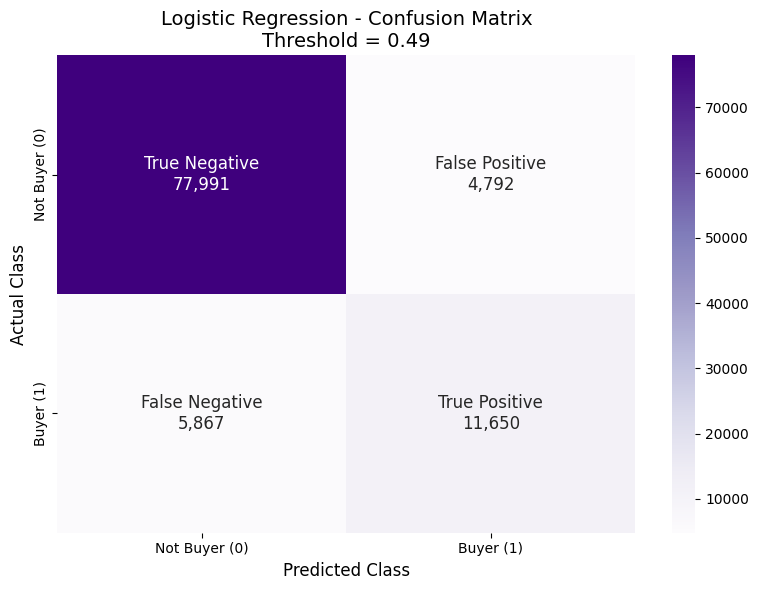


LOGISTIC REGRESSION TEST RESULTS
Accuracy  : 0.8937
Precision : 0.7086
Recall    : 0.6651
F1 Score  : 0.6861

Confusion Matrix Breakdown:
True Negatives  : 77,991
False Positives : 4,792
False Negatives : 5,867
True Positives  : 11,650

Classification Report:

               precision    recall  f1-score   support

Not Buyer (0)     0.9300    0.9421    0.9360     82783
    Buyer (1)     0.7086    0.6651    0.6861     17517

     accuracy                         0.8937    100300
    macro avg     0.8193    0.8036    0.8111    100300
 weighted avg     0.8914    0.8937    0.8924    100300



In [ ]:
# ============================================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. GET TEST PROBABILITIES
# ============================================================

lr_test_probs = best_lr_model.predict_proba(
    X_test_lr
)[:, 1]


# ============================================================
# 2. APPLY SELECTED THRESHOLD
# ============================================================

lr_test_predictions = (
    lr_test_probs >= best_lr_threshold
).astype(int)


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

lr_cm = confusion_matrix(
    y_test,
    lr_test_predictions
)

tn, fp, fn, tp = lr_cm.ravel()


# ============================================================
# 4. LABELS
# ============================================================

labels = np.array([

    [
        f"True Negative\n{tn:,}",
        f"False Positive\n{fp:,}"
    ],

    [
        f"False Negative\n{fn:,}",
        f"True Positive\n{tp:,}"
    ]

])


# ============================================================
# 5. VISUALIZE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    lr_cm,
    annot=labels,
    fmt="",
    cmap="Purples",
    cbar=True,

    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)

plt.title(
    f"Logistic Regression - Confusion Matrix\n"
    f"Threshold = {best_lr_threshold:.2f}",
    fontsize=14
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. PRINT METRICS
# ============================================================

print("\n" + "=" * 65)
print("LOGISTIC REGRESSION TEST RESULTS")
print("=" * 65)

print(
    f"Accuracy  : "
    f"{accuracy_score(y_test, lr_test_predictions):.4f}"
)

print(
    f"Precision : "
    f"{precision_score(y_test, lr_test_predictions):.4f}"
)

print(
    f"Recall    : "
    f"{recall_score(y_test, lr_test_predictions):.4f}"
)

print(
    f"F1 Score  : "
    f"{f1_score(y_test, lr_test_predictions):.4f}"
)


print("\nConfusion Matrix Breakdown:")

print(f"True Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        lr_test_predictions,
        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ],
        digits=4
    )
)

ORIGINAL DATA
Dataset shape: (668665, 15)

Target distribution:
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Target percentages:
Will_Buy_EV
No     0.8254
Yes    0.1746
Name: proportion, dtype: float64


AFTER FEATURE ENGINEERING
New dataset shape: (668665, 50)

Feature count before encoding: 48


DATA SPLIT
Train: (468065, 48)
Validation: (100300, 48)
Test: (100300, 48)

Buyer percentages:
Train: 17.46 %
Validation: 17.46 %
Test: 17.46 %

Categorical features: 9
Numeric features: 39

Encoded feature count: 73

Feature scaling completed.


LOGISTIC REGRESSION TUNING

Training: C=0.01, class_weight=None

Training: C=0.01, class_weight=balanced

Training: C=0.1, class_weight=None

Training: C=0.1, class_weight=balanced

Training: C=1.0, class_weight=None

Training: C=1.0, class_weight=balanced

Training: C=10.0, class_weight=None

Training: C=10.0, class_weight=balanced


LOGISTIC REGRESSION VALIDATION RESULTS
                        Model     C Class Weight  Thresh

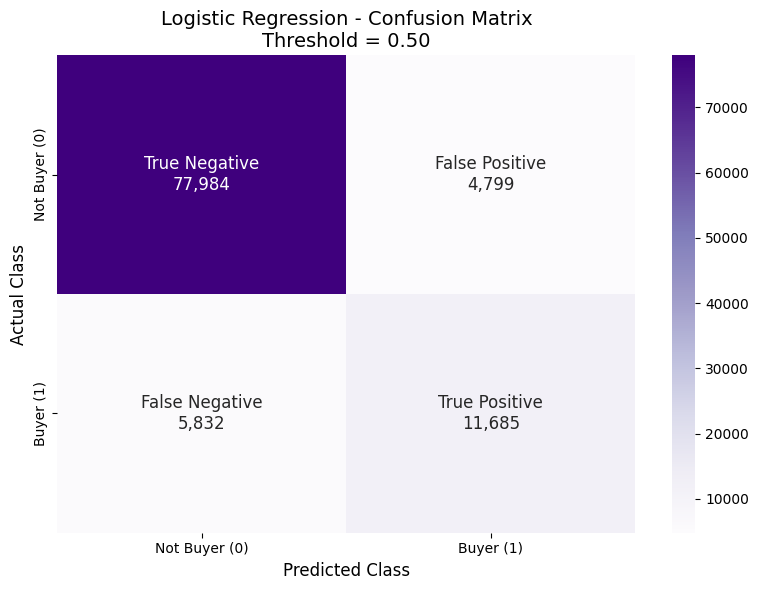



CONFUSION MATRIX BREAKDOWN
True Negatives  (actual No, predicted No)  : 77,984
False Positives (actual No, predicted Yes) : 4,799
False Negatives (actual Yes, predicted No) : 5,832
True Positives  (actual Yes, predicted Yes): 11,685


TOP 20 LOGISTIC REGRESSION FEATURES
                    Feature  Coefficient  Absolute_Coefficient
Environmental_Concern_Level      1.26735               1.26735
           Income_x_Concern      1.21934               1.21934
            Concern_Squared     -0.64254               0.64254
           Income_x_Subsidy      0.50106               0.50106
       Subsidy_Available_No     -0.45970               0.45970
             Subsidy_Binary      0.45970               0.45970
      Subsidy_Available_Yes      0.45970               0.45970
          Annual_Income_USD      0.40460               0.40460
   Range_Anxiety_Level_High     -0.27678               0.27678
          Concern_x_Subsidy      0.26357               0.26357
            Commute_Squared     -0

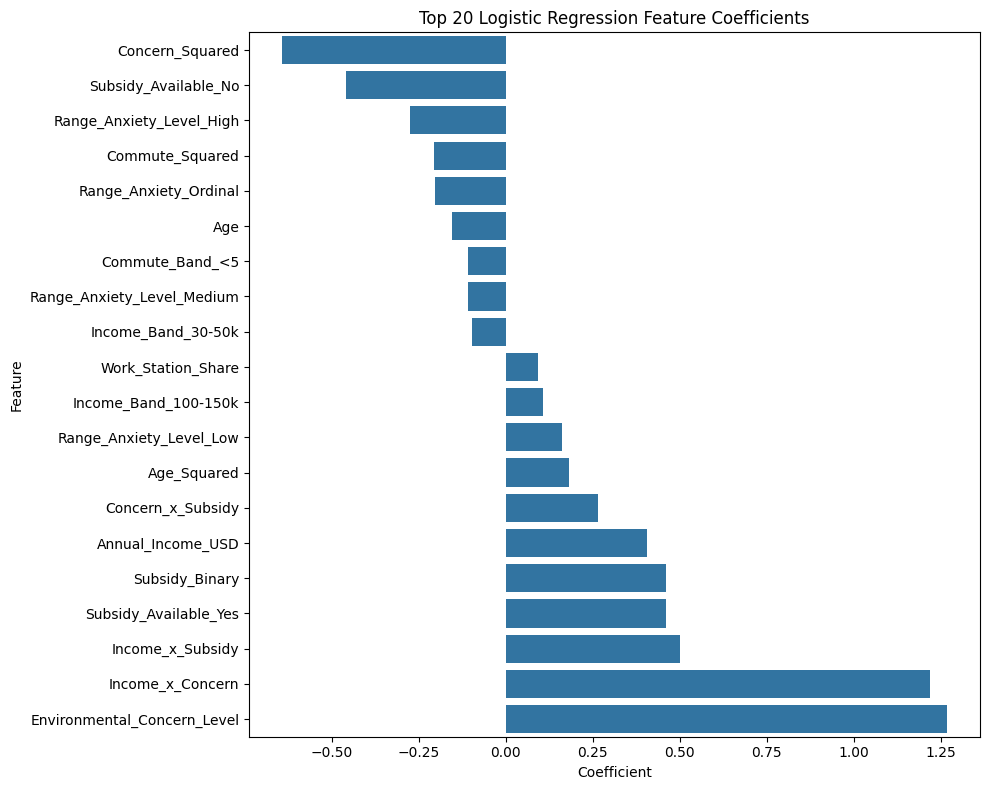

In [ ]:
# ============================================================
# EV PURCHASE PREDICTION
# LOGISTIC REGRESSION + ADVANCED FEATURE ENGINEERING
# COMPLETE PIPELINE
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. SETTINGS
# ============================================================

CSV_PATH = "/content/train.csv"

RANDOM_STATE = 42

# We want at least 65% of actual buyers detected
MIN_BUYER_RECALL = 0.65


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(
    CSV_PATH
)


print("=" * 75)
print("ORIGINAL DATA")
print("=" * 75)

print(
    "Dataset shape:",
    df.shape
)


print(
    "\nTarget distribution:"
)

print(
    df["Will_Buy_EV"]
    .value_counts()
)


print(
    "\nTarget percentages:"
)

print(
    df["Will_Buy_EV"]
    .value_counts(normalize=True)
    .round(4)
)


# ============================================================
# 4. ADVANCED FEATURE ENGINEERING
#
# Fixed transformations only.
# No validation/test information is learned here.
# ============================================================

def add_features_v2(data):

    data = data.copy()


    # ========================================================
    # A. CHARGING INFRASTRUCTURE
    # ========================================================

    data["Total_Charging_Stations"] = (
        data["Charging_Stations_Near_Home"] +
        data["Charging_Stations_Near_Work"]
    )


    data["Stations_per_Commute"] = (
        data["Total_Charging_Stations"] /
        (data["Daily_Commute_km"] + 1)
    )


    data["Commute_per_Station"] = (
        data["Daily_Commute_km"] /
        (data["Total_Charging_Stations"] + 1)
    )


    data["Station_Difference"] = (
        data["Charging_Stations_Near_Home"] -
        data["Charging_Stations_Near_Work"]
    )


    data["Station_Difference_Abs"] = (
        data["Station_Difference"].abs()
    )


    data["Home_Station_Share"] = (
        data["Charging_Stations_Near_Home"] /
        (data["Total_Charging_Stations"] + 1)
    )


    data["Work_Station_Share"] = (
        data["Charging_Stations_Near_Work"] /
        (data["Total_Charging_Stations"] + 1)
    )


    data["Stations_per_Car"] = (
        data["Total_Charging_Stations"] /
        (data["Number_of_Cars_Owned"] + 1)
    )


    # ========================================================
    # B. INCOME / AFFORDABILITY
    # ========================================================

    data["Income_per_Car"] = (
        data["Annual_Income_USD"] /
        (data["Number_of_Cars_Owned"] + 1)
    )


    data["Income_per_Commute"] = (
        data["Annual_Income_USD"] /
        (data["Daily_Commute_km"] + 1)
    )


    # Log transforms
    data["Log_Income"] = np.log1p(
        data["Annual_Income_USD"]
        .clip(lower=0)
    )


    data["Log_Commute"] = np.log1p(
        data["Daily_Commute_km"]
        .clip(lower=0)
    )


    data["Log_Total_Stations"] = np.log1p(
        data["Total_Charging_Stations"]
        .clip(lower=0)
    )


    # ========================================================
    # C. BINARY FEATURES
    # ========================================================

    data["HomeCharge_Binary"] = (
        data["Home_Charging_Possible"]
        .map({
            "Yes": 1,
            "No": 0
        })
    )


    data["Subsidy_Binary"] = (
        data["Subsidy_Available"]
        .map({
            "Yes": 1,
            "No": 0
        })
    )


    # ========================================================
    # D. RANGE ANXIETY ORDINAL FEATURE
    # ========================================================

    range_map = {

        "Low": 0,

        "Medium": 1,

        "High": 2
    }


    data["Range_Anxiety_Ordinal"] = (
        data["Range_Anxiety_Level"]
        .map(range_map)
    )


    # ========================================================
    # E. INTERACTION FEATURES
    # ========================================================

    data["HomeCharge_And_Subsidy"] = (

        data["HomeCharge_Binary"] *

        data["Subsidy_Binary"]
    )


    data["Concern_x_Subsidy"] = (

        data["Environmental_Concern_Level"] *

        data["Subsidy_Binary"]
    )


    data["Concern_x_HomeCharge"] = (

        data["Environmental_Concern_Level"] *

        data["HomeCharge_Binary"]
    )


    data["Commute_x_HomeCharge"] = (

        data["Daily_Commute_km"] *

        data["HomeCharge_Binary"]
    )


    data["Income_x_Subsidy"] = (

        data["Log_Income"] *

        data["Subsidy_Binary"]
    )


    data["Income_x_HomeCharge"] = (

        data["Log_Income"] *

        data["HomeCharge_Binary"]
    )


    data["Income_x_Concern"] = (

        data["Log_Income"] *

        data["Environmental_Concern_Level"]
    )


    data["Commute_x_RangeAnxiety"] = (

        data["Daily_Commute_km"] *

        data["Range_Anxiety_Ordinal"]
    )


    data["Stations_x_RangeAnxiety"] = (

        data["Total_Charging_Stations"] *

        data["Range_Anxiety_Ordinal"]
    )


    data["HomeCharge_x_RangeAnxiety"] = (

        data["HomeCharge_Binary"] *

        data["Range_Anxiety_Ordinal"]
    )


    data["Concern_x_RangeAnxiety"] = (

        data["Environmental_Concern_Level"] *

        data["Range_Anxiety_Ordinal"]
    )


    data["Age_x_Income"] = (

        data["Age"] *

        data["Log_Income"]
    )


    data["Age_x_Concern"] = (

        data["Age"] *

        data["Environmental_Concern_Level"]
    )


    # ========================================================
    # F. NON-LINEAR NUMERIC FEATURES
    #
    # Logistic Regression is linear, so these allow it
    # to model curved relationships.
    # ========================================================

    data["Age_Squared"] = (
        data["Age"] ** 2
    )


    data["Commute_Squared"] = (
        data["Daily_Commute_km"] ** 2
    )


    data["Concern_Squared"] = (
        data["Environmental_Concern_Level"] ** 2
    )


    # ========================================================
    # G. AGE BANDS
    # ========================================================

    data["Age_Band"] = pd.cut(

        data["Age"],

        bins=[
            -np.inf,
            25,
            35,
            45,
            55,
            65,
            np.inf
        ],

        labels=[
            "<=25",
            "26-35",
            "36-45",
            "46-55",
            "56-65",
            "65+"
        ]
    )


    # ========================================================
    # H. INCOME BANDS
    # ========================================================

    data["Income_Band"] = pd.cut(

        data["Annual_Income_USD"],

        bins=[
            -np.inf,
            30000,
            50000,
            75000,
            100000,
            150000,
            np.inf
        ],

        labels=[
            "<30k",
            "30-50k",
            "50-75k",
            "75-100k",
            "100-150k",
            "150k+"
        ]
    )


    # ========================================================
    # I. COMMUTE BANDS
    # ========================================================

    data["Commute_Band"] = pd.cut(

        data["Daily_Commute_km"],

        bins=[
            -np.inf,
            5,
            15,
            30,
            50,
            np.inf
        ],

        labels=[
            "<5",
            "5-15",
            "15-30",
            "30-50",
            "50+"
        ]
    )


    return data


# Apply feature engineering
df = add_features_v2(
    df
)


print("\n")
print("=" * 75)
print("AFTER FEATURE ENGINEERING")
print("=" * 75)

print(
    "New dataset shape:",
    df.shape
)


# ============================================================
# 5. CREATE TARGET y
# ============================================================

y = (

    df["Will_Buy_EV"]

    .map({
        "No": 0,
        "Yes": 1
    })

    .astype(int)
)


# ============================================================
# 6. CREATE FEATURES X
#
# Remove target and ID.
# ============================================================

X = df.drop(

    columns=[
        "Will_Buy_EV",
        "id"
    ],

    errors="ignore"
)


print(
    "\nFeature count before encoding:",
    X.shape[1]
)


# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
#
# 70% train
# 15% validation
# 15% final test
#
# Stratification keeps the same buyer ratio.
# ============================================================

X_train, X_temp, y_train, y_temp = (
    train_test_split(

        X,

        y,

        test_size=0.30,

        stratify=y,

        random_state=RANDOM_STATE
    )
)


X_val, X_test, y_val, y_test = (
    train_test_split(

        X_temp,

        y_temp,

        test_size=0.50,

        stratify=y_temp,

        random_state=RANDOM_STATE
    )
)


print("\n")
print("=" * 75)
print("DATA SPLIT")
print("=" * 75)


print(
    "Train:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Test:",
    X_test.shape
)


print("\nBuyer percentages:")


print(
    "Train:",
    round(
        y_train.mean() * 100,
        2
    ),
    "%"
)


print(
    "Validation:",
    round(
        y_val.mean() * 100,
        2
    ),
    "%"
)


print(
    "Test:",
    round(
        y_test.mean() * 100,
        2
    ),
    "%"
)


# ============================================================
# 8. DEFINE CATEGORICAL FEATURES
# ============================================================

categorical_cols = [

    "Gender",

    "City_Type",

    "Current_Car_Type",

    "Home_Charging_Possible",

    "Subsidy_Available",

    "Range_Anxiety_Level",

    # New engineered categories
    "Age_Band",

    "Income_Band",

    "Commute_Band"
]


# Keep only columns that actually exist
categorical_cols = [

    col

    for col in categorical_cols

    if col in X_train.columns
]


numeric_cols = [

    col

    for col in X_train.columns

    if col not in categorical_cols
]


print(
    "\nCategorical features:",
    len(categorical_cols)
)

print(
    "Numeric features:",
    len(numeric_cols)
)


# ============================================================
# 9. HANDLE MISSING VALUES
#
# IMPORTANT:
# Values are learned from TRAINING DATA ONLY.
# ============================================================

X_train = X_train.copy()

X_val = X_val.copy()

X_test = X_test.copy()


# ------------------------------------------------------------
# NUMERIC
# ------------------------------------------------------------

for col in numeric_cols:

    median_value = (
        X_train[col]
        .median()
    )


    X_train[col] = (
        X_train[col]
        .fillna(median_value)
    )


    X_val[col] = (
        X_val[col]
        .fillna(median_value)
    )


    X_test[col] = (
        X_test[col]
        .fillna(median_value)
    )


# ------------------------------------------------------------
# CATEGORICAL
# ------------------------------------------------------------

for col in categorical_cols:

    X_train[col] = (

        X_train[col]

        .astype("object")

        .fillna("Missing")

        .astype(str)
    )


    X_val[col] = (

        X_val[col]

        .astype("object")

        .fillna("Missing")

        .astype(str)
    )


    X_test[col] = (

        X_test[col]

        .astype("object")

        .fillna("Missing")

        .astype(str)
    )


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

X_train_enc = pd.get_dummies(

    X_train,

    columns=categorical_cols,

    drop_first=False,

    dtype=float
)


X_val_enc = pd.get_dummies(

    X_val,

    columns=categorical_cols,

    drop_first=False,

    dtype=float
)


X_test_enc = pd.get_dummies(

    X_test,

    columns=categorical_cols,

    drop_first=False,

    dtype=float
)


# ============================================================
# 11. ALIGN VALIDATION / TEST COLUMNS
#
# They must exactly match training.
# ============================================================

X_val_enc = X_val_enc.reindex(

    columns=X_train_enc.columns,

    fill_value=0
)


X_test_enc = X_test_enc.reindex(

    columns=X_train_enc.columns,

    fill_value=0
)


print(
    "\nEncoded feature count:",
    X_train_enc.shape[1]
)


# ============================================================
# 12. SCALE FEATURES
#
# Logistic Regression benefits from scaling.
#
# Scaler is FIT ONLY on training data.
# ============================================================

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train_enc
)


X_val_scaled = scaler.transform(
    X_val_enc
)


X_test_scaled = scaler.transform(
    X_test_enc
)


print(
    "\nFeature scaling completed."
)


# ============================================================
# 13. FUNCTION TO FIND BEST THRESHOLD
#
# Goal:
#
# Highest validation accuracy
# while buyer recall >= 65%.
# ============================================================

def find_best_threshold(
    y_true,
    probabilities,
    min_buyer_recall=0.65
):

    rows = []


    for threshold in np.arange(
        0.01,
        1.00,
        0.01
    ):

        predictions = (

            probabilities >= threshold

        ).astype(int)


        rows.append({

            "Threshold":
                threshold,

            "Accuracy":
                accuracy_score(
                    y_true,
                    predictions
                ),

            "Buyer Precision":
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "Buyer Recall":
                recall_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "Buyer F1":
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true,
                    predictions
                )
        })


    threshold_df = pd.DataFrame(
        rows
    )


    eligible = threshold_df[

        threshold_df["Buyer Recall"]

        >= min_buyer_recall
    ]


    # If recall requirement can be satisfied
    if len(eligible) > 0:

        eligible = (

            eligible

            .sort_values(

                by=[
                    "Accuracy",
                    "Buyer F1",
                    "Buyer Precision"
                ],

                ascending=False
            )
        )


        best = eligible.iloc[0]


    # Fallback if no threshold reaches 65% recall
    else:

        print(
            "\nWARNING: "
            "No threshold achieved minimum buyer recall."
        )


        best = threshold_df.loc[

            threshold_df[
                "Buyer F1"
            ].idxmax()
        ]


    return best, threshold_df


# ============================================================
# 14. LOGISTIC REGRESSION HYPERPARAMETER SEARCH
#
# Fine-tune:
#
# C
# class_weight
# ============================================================

C_VALUES = [

    0.01,

    0.1,

    1.0,

    10.0
]


CLASS_WEIGHTS = [

    None,

    "balanced"
]


logistic_results = []

trained_models = {}


print("\n")
print("=" * 75)
print("LOGISTIC REGRESSION TUNING")
print("=" * 75)


for C in C_VALUES:

    for class_weight in CLASS_WEIGHTS:


        model_name = (
            f"C={C}, "
            f"class_weight={class_weight}"
        )


        print(
            "\nTraining:",
            model_name
        )


        model = LogisticRegression(

            C=C,

            penalty="l2",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=2000,

            random_state=RANDOM_STATE
        )


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.fit(

            X_train_scaled,

            y_train
        )


        # ----------------------------------------------------
        # VALIDATION PROBABILITIES
        # ----------------------------------------------------

        val_probs = (

            model.predict_proba(
                X_val_scaled
            )[:, 1]
        )


        # ----------------------------------------------------
        # FIND BEST THRESHOLD
        # ----------------------------------------------------

        best_threshold_result, _ = (
            find_best_threshold(

                y_val,

                val_probs,

                min_buyer_recall=
                    MIN_BUYER_RECALL
            )
        )


        threshold = float(

            best_threshold_result[
                "Threshold"
            ]
        )


        val_predictions = (

            val_probs >= threshold

        ).astype(int)


        # Store model
        trained_models[
            model_name
        ] = model


        # Store validation results
        logistic_results.append({

            "Model":
                model_name,

            "C":
                C,

            "Class Weight":
                str(class_weight),

            "Threshold":
                threshold,

            "Accuracy":
                accuracy_score(
                    y_val,
                    val_predictions
                ),

            "Buyer Precision":
                precision_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Buyer Recall":
                recall_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Buyer F1":
                f1_score(
                    y_val,
                    val_predictions,
                    zero_division=0
                ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_val,
                    val_predictions
                ),

            "ROC AUC":
                roc_auc_score(
                    y_val,
                    val_probs
                ),

            "PR AUC":
                average_precision_score(
                    y_val,
                    val_probs
                )
        })


# ============================================================
# 15. VALIDATION COMPARISON
# ============================================================

logistic_results_df = pd.DataFrame(
    logistic_results
)


logistic_results_df = (

    logistic_results_df

    .sort_values(

        by=[
            "Accuracy",
            "Buyer F1",
            "PR AUC"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 105)
print("LOGISTIC REGRESSION VALIDATION RESULTS")
print("=" * 105)


print(

    logistic_results_df

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 16. SELECT BEST LOGISTIC REGRESSION
#
# Selection uses VALIDATION only.
# ============================================================

best_row = (
    logistic_results_df
    .iloc[0]
)


BEST_MODEL_NAME = (
    best_row["Model"]
)


BEST_THRESHOLD = float(
    best_row["Threshold"]
)


best_logistic_model = (
    trained_models[
        BEST_MODEL_NAME
    ]
)


print("\n")
print("=" * 75)
print("SELECTED LOGISTIC REGRESSION MODEL")
print("=" * 75)


print(
    "Model:",
    BEST_MODEL_NAME
)


print(
    "Threshold:",
    round(
        BEST_THRESHOLD,
        2
    )
)


print(
    "Validation Accuracy:",
    round(
        best_row["Accuracy"],
        4
    )
)


print(
    "Validation Buyer Precision:",
    round(
        best_row["Buyer Precision"],
        4
    )
)


print(
    "Validation Buyer Recall:",
    round(
        best_row["Buyer Recall"],
        4
    )
)


print(
    "Validation Buyer F1:",
    round(
        best_row["Buyer F1"],
        4
    )
)


# ============================================================
# 17. FINAL TEST PROBABILITIES
#
# Test data has NOT been used to:
#
# - select C
# - select class_weight
# - select threshold
# ============================================================

test_probs = (

    best_logistic_model

    .predict_proba(
        X_test_scaled
    )[:, 1]
)


# ============================================================
# 18. FINAL TEST YES / NO PREDICTIONS
# ============================================================

test_predictions = (

    test_probs >= BEST_THRESHOLD

).astype(int)


# Every test row now gets:
#
# 0 = Not Buyer / No
# 1 = Buyer / Yes


# ============================================================
# 19. FINAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)


test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)


test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)


test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)


test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        test_predictions
    )
)


test_roc_auc = roc_auc_score(
    y_test,
    test_probs
)


test_pr_auc = (
    average_precision_score(
        y_test,
        test_probs
    )
)


# ============================================================
# 20. PRINT FINAL TEST RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("FINAL LOGISTIC REGRESSION TEST RESULTS")
print("=" * 75)


print(
    f"Model              : "
    f"{BEST_MODEL_NAME}"
)


print(
    f"Threshold          : "
    f"{BEST_THRESHOLD:.2f}"
)


print(
    f"Accuracy           : "
    f"{test_accuracy:.4f}"
)


print(
    f"Buyer Precision    : "
    f"{test_precision:.4f}"
)


print(
    f"Buyer Recall       : "
    f"{test_recall:.4f}"
)


print(
    f"Buyer F1           : "
    f"{test_f1:.4f}"
)


print(
    f"Balanced Accuracy  : "
    f"{test_balanced_accuracy:.4f}"
)


print(
    f"ROC-AUC            : "
    f"{test_roc_auc:.4f}"
)


print(
    f"PR-AUC             : "
    f"{test_pr_auc:.4f}"
)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print(
    "\nClassification Report:\n"
)


print(

    classification_report(

        y_test,

        test_predictions,

        target_names=[

            "Not Buyer (0)",

            "Buyer (1)"
        ],

        digits=4
    )
)


# ============================================================
# 22. CONFUSION / CLASSIFICATION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    test_predictions
)


tn, fp, fn, tp = (
    cm.ravel()
)


# Custom labels
matrix_labels = np.array([

    [
        f"True Negative\n{tn:,}",

        f"False Positive\n{fp:,}"
    ],

    [
        f"False Negative\n{fn:,}",

        f"True Positive\n{tp:,}"
    ]
])


# ============================================================
# 23. VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    cm,

    annot=matrix_labels,

    fmt="",

    cmap="Purples",

    cbar=True,

    xticklabels=[

        "Not Buyer (0)",

        "Buyer (1)"
    ],

    yticklabels=[

        "Not Buyer (0)",

        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)


plt.title(

    "Logistic Regression - Confusion Matrix\n"

    f"Threshold = {BEST_THRESHOLD:.2f}",

    fontsize=14
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "Actual Class",
    fontsize=12
)


plt.tight_layout()

plt.show()


# ============================================================
# 24. CONFUSION MATRIX BREAKDOWN
# ============================================================

print("\n")
print("=" * 75)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 75)


print(
    f"True Negatives  "
    f"(actual No, predicted No)  : "
    f"{tn:,}"
)


print(
    f"False Positives "
    f"(actual No, predicted Yes) : "
    f"{fp:,}"
)


print(
    f"False Negatives "
    f"(actual Yes, predicted No) : "
    f"{fn:,}"
)


print(
    f"True Positives  "
    f"(actual Yes, predicted Yes): "
    f"{tp:,}"
)


# ============================================================
# 25. OPTIONAL:
# SHOW MOST IMPORTANT LOGISTIC REGRESSION FEATURES
#
# Positive coefficient:
# pushes prediction toward Buyer (1)
#
# Negative coefficient:
# pushes prediction toward Not Buyer (0)
# ============================================================

coefficient_df = pd.DataFrame({

    "Feature":
        X_train_enc.columns,

    "Coefficient":
        best_logistic_model.coef_[0]
})


coefficient_df[
    "Absolute_Coefficient"
] = (

    coefficient_df[
        "Coefficient"
    ].abs()
)


coefficient_df = (

    coefficient_df

    .sort_values(

        "Absolute_Coefficient",

        ascending=False
    )
)


print("\n")
print("=" * 75)
print("TOP 20 LOGISTIC REGRESSION FEATURES")
print("=" * 75)


print(

    coefficient_df[

        [
            "Feature",
            "Coefficient",
            "Absolute_Coefficient"
        ]

    ]

    .head(20)

    .round(5)

    .to_string(
        index=False
    )
)


# ============================================================
# 26. FEATURE COEFFICIENT VISUALIZATION
# ============================================================

top_features = (

    coefficient_df

    .head(20)

    .sort_values(
        "Coefficient"
    )
)


plt.figure(
    figsize=(10, 8)
)


sns.barplot(

    data=top_features,

    x="Coefficient",

    y="Feature"
)


plt.title(
    "Top 20 Logistic Regression Feature Coefficients"
)


plt.xlabel(
    "Coefficient"
)


plt.ylabel(
    "Feature"
)


plt.tight_layout()

plt.show()

Best threshold: 0.49

Accuracy: 0.8976
Precision: 0.7178
Recall: 0.6812
F1: 0.699
Balanced Accuracy: 0.8123
ROC-AUC: 0.9416
PR-AUC: 0.7546

Classification Report:

              precision    recall  f1-score   support

   Not Buyer     0.9333    0.9433    0.9383     82783
       Buyer     0.7178    0.6812    0.6990     17517

    accuracy                         0.8976    100300
   macro avg     0.8255    0.8123    0.8187    100300
weighted avg     0.8956    0.8976    0.8965    100300



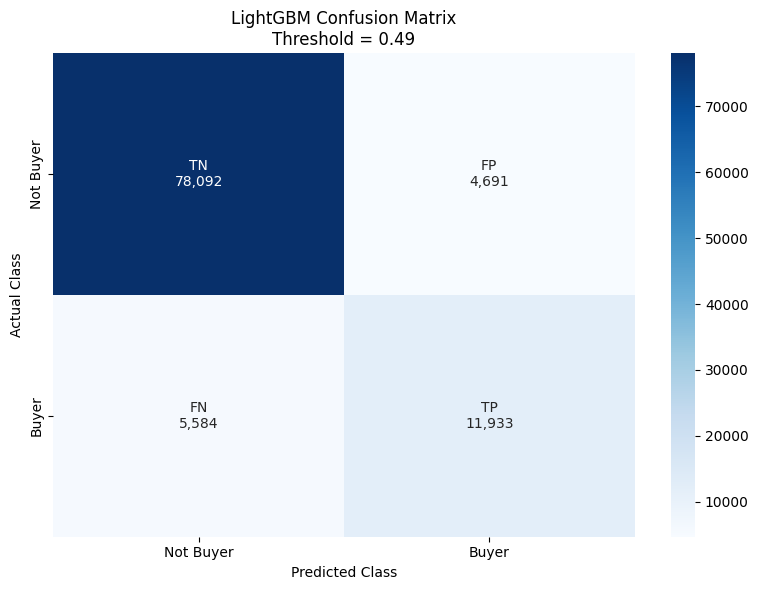

In [ ]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. TRAIN LIGHTGBM
# ============================================================

lgb_model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.0,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_enc,
    y_train
)


# ============================================================
# 2. VALIDATION PROBABILITIES
# ============================================================

val_probs = lgb_model.predict_proba(
    X_val_enc
)[:, 1]


# ============================================================
# 3. FIND BEST THRESHOLD
#    highest accuracy with recall >= 65%
# ============================================================

best_threshold = None
best_accuracy = -1

for threshold in np.arange(0.01, 1.00, 0.01):

    val_pred = (
        val_probs >= threshold
    ).astype(int)

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    if recall >= 0.65 and accuracy > best_accuracy:

        best_accuracy = accuracy
        best_threshold = threshold


# fallback
if best_threshold is None:
    best_threshold = 0.50


print(
    f"Best threshold: {best_threshold:.2f}"
)


# ============================================================
# 4. TEST PREDICTIONS
# ============================================================

test_probs = lgb_model.predict_proba(
    X_test_enc
)[:, 1]

test_pred = (
    test_probs >= best_threshold
).astype(int)


# ============================================================
# 5. METRICS
# ============================================================

print("\nAccuracy:",
      round(accuracy_score(y_test, test_pred), 4))

print("Precision:",
      round(precision_score(y_test, test_pred), 4))

print("Recall:",
      round(recall_score(y_test, test_pred), 4))

print("F1:",
      round(f1_score(y_test, test_pred), 4))

print("Balanced Accuracy:",
      round(
          balanced_accuracy_score(
              y_test,
              test_pred
          ),
          4
      ))

print("ROC-AUC:",
      round(
          roc_auc_score(
              y_test,
              test_probs
          ),
          4
      ))

print("PR-AUC:",
      round(
          average_precision_score(
              y_test,
              test_probs
          ),
          4
      ))


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Not Buyer",
            "Buyer"
        ],
        digits=4
    )
)


# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_pred
)

tn, fp, fn, tp = cm.ravel()

labels = np.array([
    [
        f"TN\n{tn:,}",
        f"FP\n{fp:,}"
    ],
    [
        f"FN\n{fn:,}",
        f"TP\n{tp:,}"
    ]
])


plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=[
        "Not Buyer",
        "Buyer"
    ],
    yticklabels=[
        "Not Buyer",
        "Buyer"
    ]
)

plt.title(
    f"LightGBM Confusion Matrix\n"
    f"Threshold = {best_threshold:.2f}"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SIMPLE LIGHTGBM - ORIGINAL FEATURES
# 5-FOLD STRATIFIED CROSS VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("/content/train.csv")


# ============================================================
# 2. TARGET
# ============================================================

y = df["Will_Buy_EV"].map({
    "No": 0,
    "Yes": 1
}).astype(int)


# ============================================================
# 3. ORIGINAL FEATURES ONLY
#
# No feature engineering.
# Only remove target and ID.
# ============================================================

X = df.drop(
    columns=[
        "Will_Buy_EV",
        "id"
    ],
    errors="ignore"
)


# ============================================================
# 4. CATEGORICAL COLUMNS
# ============================================================

categorical_cols = [

    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]


categorical_cols = [
    col
    for col in categorical_cols
    if col in X.columns
]


# LightGBM can directly work with categorical features
for col in categorical_cols:

    X[col] = (
        X[col]
        .fillna("Missing")
        .astype("category")
    )


# ============================================================
# 5. 5-FOLD STRATIFIED CROSS VALIDATION
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


fold_results = []


for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(
        f"\n========== FOLD {fold} =========="
    )


    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]


    # ========================================================
    # MODEL
    # ========================================================

    model = LGBMClassifier(

        n_estimators=700,

        learning_rate=0.04,

        num_leaves=31,

        min_child_samples=30,

        subsample=0.90,

        colsample_bytree=0.90,

        reg_alpha=0.05,

        reg_lambda=2.0,

        objective="binary",

        random_state=42,

        n_jobs=-1,

        verbosity=-1
    )


    # ========================================================
    # TRAIN
    # ========================================================

    model.fit(
        X_train,
        y_train,
        categorical_feature=categorical_cols
    )


    # ========================================================
    # PREDICT
    # ========================================================

    probabilities = model.predict_proba(
        X_val
    )[:, 1]


    # Standard threshold
    predictions = (
        probabilities >= 0.50
    ).astype(int)


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_val,
        predictions
    )

    roc_auc = roc_auc_score(
        y_val,
        probabilities
    )

    pr_auc = average_precision_score(
        y_val,
        probabilities
    )


    fold_results.append({

        "Fold": fold,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Balanced Accuracy":
            balanced_acc,

        "ROC AUC":
            roc_auc,

        "PR AUC":
            pr_auc
    })


    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1        : {f1:.4f}"
    )

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC    : {pr_auc:.4f}"
    )


# ============================================================
# 6. RESULTS TABLE
# ============================================================

cv_results = pd.DataFrame(
    fold_results
)


print("\n")
print("=" * 80)
print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 80)

print(
    cv_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 7. MEAN PERFORMANCE
# ============================================================

print("\n")
print("=" * 80)
print("AVERAGE 5-FOLD PERFORMANCE")
print("=" * 80)


print(
    cv_results
    .drop(columns="Fold")
    .mean()
    .round(4)
)


print("\nStandard deviation:")

print(
    cv_results
    .drop(columns="Fold")
    .std()
    .round(4)
)


========== FOLD 1 ==========
Accuracy  : 0.8976
Precision : 0.7251
Recall    : 0.6662
F1        : 0.6944
ROC-AUC   : 0.9405
PR-AUC    : 0.7504

========== FOLD 2 ==========
Accuracy  : 0.8981
Precision : 0.7232
Recall    : 0.6744
F1        : 0.6980
ROC-AUC   : 0.9415
PR-AUC    : 0.7568

========== FOLD 3 ==========
Accuracy  : 0.8992
Precision : 0.7282
Recall    : 0.6744
F1        : 0.7002
ROC-AUC   : 0.9429
PR-AUC    : 0.7584

========== FOLD 4 ==========
Accuracy  : 0.8988
Precision : 0.7272
Recall    : 0.6727
F1        : 0.6989
ROC-AUC   : 0.9423
PR-AUC    : 0.7579

========== FOLD 5 ==========
Accuracy  : 0.8992
Precision : 0.7295
Recall    : 0.6720
F1        : 0.6996
ROC-AUC   : 0.9417
PR-AUC    : 0.7553


5-FOLD CROSS VALIDATION RESULTS
 Fold  Accuracy  Precision  Recall     F1  Balanced Accuracy  ROC AUC  PR AUC
    1    0.8976     0.7251  0.6662 0.6944             0.8064   0.9405  0.7504
    2    0.8981     0.7232  0.6744 0.6980             0.8099   0.9415  0.7568
    3    0.8

Training fold 1...
Training fold 2...
Training fold 3...
Training fold 4...
Training fold 5...


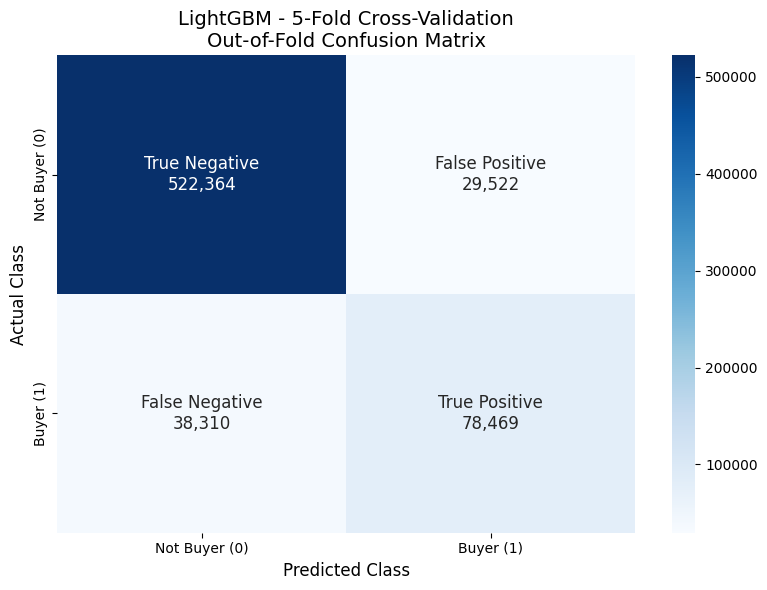


5-FOLD OUT-OF-FOLD RESULTS
Accuracy  : 0.8986
Precision : 0.7266
Recall    : 0.6719
F1 Score  : 0.6982

Confusion Matrix Breakdown:
True Negatives  : 522,364
False Positives : 29,522
False Negatives : 38,310
True Positives  : 78,469

Classification Report:

               precision    recall  f1-score   support

Not Buyer (0)     0.9317    0.9465    0.9390    551886
    Buyer (1)     0.7266    0.6719    0.6982    116779

     accuracy                         0.8986    668665
    macro avg     0.8291    0.8092    0.8186    668665
 weighted avg     0.8959    0.8986    0.8970    668665



In [ ]:
# ============================================================
# 5-FOLD LIGHTGBM
# OUT-OF-FOLD CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. 5-FOLD CV
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Every row will eventually receive one prediction
oof_predictions = np.zeros(
    len(X),
    dtype=int
)

oof_probabilities = np.zeros(
    len(X)
)


for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(
        f"Training fold {fold}..."
    )


    X_train = X.iloc[
        train_idx
    ].copy()

    X_val = X.iloc[
        val_idx
    ].copy()


    y_train = y.iloc[
        train_idx
    ]

    y_val = y.iloc[
        val_idx
    ]


    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------

    model = LGBMClassifier(
        n_estimators=700,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.05,
        reg_lambda=2.0,
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )


    model.fit(
        X_train,
        y_train,
        categorical_feature=categorical_cols
    )


    # --------------------------------------------------------
    # Predict validation fold
    # --------------------------------------------------------

    fold_probs = model.predict_proba(
        X_val
    )[:, 1]


    fold_pred = (
        fold_probs >= 0.50
    ).astype(int)


    # Store predictions in original row positions
    oof_probabilities[
        val_idx
    ] = fold_probs


    oof_predictions[
        val_idx
    ] = fold_pred


# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y,
    oof_predictions
)


tn, fp, fn, tp = (
    cm.ravel()
)


labels = np.array([

    [
        f"True Negative\n{tn:,}",
        f"False Positive\n{fp:,}"
    ],

    [
        f"False Negative\n{fn:,}",
        f"True Positive\n{tp:,}"
    ]

])


# ============================================================
# 3. PLOT
# ============================================================

plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,

    xticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    yticklabels=[
        "Not Buyer (0)",
        "Buyer (1)"
    ],

    annot_kws={
        "size": 12
    }
)


plt.title(
    "LightGBM - 5-Fold Cross-Validation\n"
    "Out-of-Fold Confusion Matrix",
    fontsize=14
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "Actual Class",
    fontsize=12
)


plt.tight_layout()
plt.show()


# ============================================================
# 4. OVERALL CV METRICS
# ============================================================

print("\n" + "=" * 70)
print("5-FOLD OUT-OF-FOLD RESULTS")
print("=" * 70)


print(
    f"Accuracy  : "
    f"{accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"Precision : "
    f"{precision_score(y, oof_predictions):.4f}"
)

print(
    f"Recall    : "
    f"{recall_score(y, oof_predictions):.4f}"
)

print(
    f"F1 Score  : "
    f"{f1_score(y, oof_predictions):.4f}"
)


print("\nConfusion Matrix Breakdown:")

print(
    f"True Negatives  : {tn:,}"
)

print(
    f"False Positives : {fp:,}"
)

print(
    f"False Negatives : {fn:,}"
)

print(
    f"True Positives  : {tp:,}"
)


print("\nClassification Report:\n")


print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Not Buyer (0)",
            "Buyer (1)"
        ],
        digits=4
    )
)